# Harvesting the volatility risk premium — a complete synthetic walkthrough

This notebook implements the **main methodology** in Maciej Wysocki's
*Harvesting the Volatility Risk Premium: A Learning-to-Rank Approach*
(arXiv:2608.24786v1), using fabricated observations. Read it alongside the
[local paper extraction](../../docs/research/papers/Harvesting_the_Volatility_Risk_Premium_A_Learning_to_Rank_Approach.md).

**Synthetic data; not a reproduction of the reported performance.** Code,
intermediate tables, fitted models, calibration curves and executed results are
visible here. No Apollo3 data store, API keys or downloaded market history are needed.

We follow the complete decision flow:

1. Synthetic minute SPX paths, IV surfaces and option chains.
2. Eight short-put delta buckets plus SKIP; entry at 10:00 ET, unhedged to expiry.
3. The disclosed feature catalog, with timestamps, ranks and seven products.
4. Path-aware trade labels and frozen training-only relevance grades.
5. S1–S5 feature selection, independently at each annual boundary.
6. LightGBM LambdaRank: 50 Optuna TPE trials, tuning/early-stop/gate date roles.
7. Confidence-gap calibration, seven position-size calibrations, margin and fees.
8. Continuous walk-forward NAV, the untouched 2025 hold-out, diagnostics,
   execution stress and reusable feature/control ablations.

The default run uses the **paper's full five-window / 250-trial search**, not a
reduced demo budget. The final optional cells expose expensive robustness
reruns without automatically launching another study.

## What is reproduced, and what must be reconstructed

| Topic | Implementation and authority |
|---|---|
| Published settings | Use the paper's feature windows, selection thresholds/caps, labels, search ranges, 50 trials, 2000-round ceiling, 50-round patience, annual dates, sizing grids, margin and fees. |
| Fake market | A reproducible stochastic SPX/IV/event generator. Its parameters describe a made-up market, not trading recommendations. Every synthetic day has a same-session expiry, including 2018–2022. This deliberately avoids inventing the source's unresolved overnight ledger. |
| Calendar | Real NYSE sessions and close times, but **fabricated** macro-release dates. FOMC-like announcement sessions are excluded before candidate-history construction. |
| Surface observations | Synthetic delta/tenor/snapshot quotes stand in for a vendor's already-extracted IV surface. Linear interpolation on its delta nodes; exactly available tenor targets. No claim to reproduce undisclosed vendor cleaning or IV inversion. |
| Greek conventions | Long-option signed delta/theta, gamma and vega; theta per year and vega per unit decimal IV. Put targets are negative signed deltas when computing the target gap. |
| Missing/undefined values | Full rolling windows; undefined feature ratios/correlations remain NaN, never infinity. No zero-fill, standardization or winsorization. Undefined correlation is not evidence of relevance. |
| Within-day ranks | Descending values, average ties; real ranks 1–8, SKIP 8.5. IV-gap rank is available at entry, resolving the source's timing ambiguity explicitly. |
| Feature selection | Continuous path score for relevance; connected components of the within-scope correlation graph; source-catalog group order, then nonmissing fraction, then feature name resolve representative ties. Three expanding prefixes end at the three equal partitions of available training dates. |
| Labels / temporal roles | Quantile thresholds for search fit only its fitting dates; refit thresholds fit only refit fitting dates. Feature selection follows the source's broader pre-gate training window, which includes tuning/early-stop dates. This is disclosed, not misrepresented as nested feature selection. |
| Gate | **User-approved reconstruction:** evaluate every distinct observed held-out score gap, including zero. One-contract net P&L divided by $5M is the gate's comparable return series. Ties favor the smaller threshold. Undefined all-cash Sortino is excluded; a positive-return series with zero downside has +infinity Sortino. |
| 2025 gate | Pool the four archived, genuinely held-out WF gate predictions. Never rescore those dates with the 2025 fit, which has seen them. The paper does not fully settle this model/union detail. |
| Sizing | RV uses completed prior sessions. SRS cap is the 95th percentile of median-normalized richness; EA uses a right-continuous empirical CDF. GB adverse move is the decline from entry to that day's low. |
| Kelly | Use each bucket's preceding 252 eligible, hypothetical one-contract net returns on actual Reg-T margin, regardless of whether that bucket was selected. Require the complete source-defined 252-day window; undefined/nonpositive edge means zero size. This resolves an undisclosed history convention. |
| Size calibration | Use predictions on the model's fitting rows, as the paper does. Gate hold-outs remain excluded. Grid ties favor the smaller parameter. Failure to reach 16% is reported, not repaired by raising grid caps. |
| Statistical tests | Show both printed and prose DSR references. The paper's 75-trial count is a **paper-budget illustration**, not the correct count for this notebook's exhaustive gate search or any later experiments. |
| Baselines | Actual PUT/WPUT data are unavailable here. Use labeled synthetic controls; do not manufacture historical index results. |

All source ambiguities remain visible. This is an executable reconstruction of
the disclosed method, not a claim to possess the authors' undisclosed code.

## Environment

Select the Python kernel belonging to `A3_PYENV_DIR` from `cmd/DEV` (in this repo,
`./venv`). Packages: numpy, pandas, scipy, LightGBM, Optuna, matplotlib,
pandas-market-calendars, IPython. The notebook does not install packages or read
the secret-bearing DEV file. To reproduce headlessly, use the environment's
Python and `jupyter nbconvert --execute --to notebook` with no cell timeout.

In [1]:
import os
import sys
import time
import itertools
from collections import Counter
from importlib.metadata import version

import numpy as np
import pandas as pd
import scipy.stats as st
from scipy.special import ndtr, ndtri
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
import lightgbm as lgb
import optuna
import matplotlib.pyplot as plt
import pandas_market_calendars as mcal
from IPython.display import display

started = time.perf_counter()
SEED = 260824786  # Notebook reconstruction seed; none is published.
rng = np.random.default_rng(SEED)
ANN = 252
NAV0 = 5_000_000.0
TARGET_DELTAS = np.array([.05, .10, .15, .20, .25, .30, .40, .45])
CANDIDATES = [f'P{round(100*d):02d}' for d in TARGET_DELTAS] + ['SKIP']
GAIN = np.array([0, 1, 3, 7, 15])
GRADE_QUANTILES = [.10, .40, .60, .90]
PAPER_TRIALS = 50
PAPER_ROUNDS = 2000
PAPER_PATIENCE = 50
PREDICTION_YEARS = range(2021, 2026)

optuna.logging.set_verbosity(optuna.logging.WARNING)
display(pd.Series({p: version(p) for p in
    ['numpy', 'pandas', 'scipy', 'lightgbm', 'optuna', 'matplotlib']}, name='version'))
print('Kernel:', sys.executable)

numpy          2.4.2
pandas         2.3.3
scipy         1.17.1
lightgbm       4.7.0
optuna         4.5.0
matplotlib    3.10.8
Name: version, dtype: object

Kernel: /Users/constantinpavlicu/dev/apollo3/venv/bin/python


## 1. Synthetic observations, not random feature columns

Generate a latent volatility process and minute SPX moves. Implied volatility
can exceed realized volatility, while spot declines can lift the synthetic IV
surface. These are generator assumptions, not fitted trading signals. The model
never sees latent volatility or future prices.

The synthetic IV surface has three snapshots (09:35, 10:00, close), a term
structure and downside skew. These snapshots also define the surface's observed
intraday range. Use every NYSE session from the paper's 2017 warm-up through
2025. Holiday early closes determine the actual path duration.

,entry,close,VIX,VVIX
2017-01-03,2492.606436,2495.817963,22.301604,93.634535
2017-01-04,2507.701435,2535.619122,21.163811,89.180752
2017-01-05,2559.430686,2549.251707,22.418825,84.556561
2017-01-06,2562.345094,2512.259932,21.466660,88.088287
2017-01-09,2526.302647,2509.758185,23.071621,89.231915


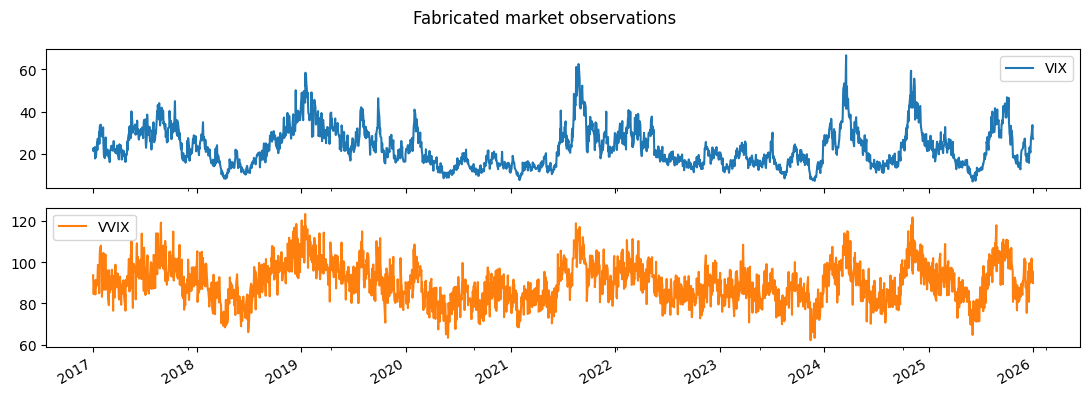

In [2]:
schedule = mcal.get_calendar('NYSE').schedule('2017-01-01', '2025-12-31')
dates = schedule.index.tz_localize(None)
day_minutes = ((schedule.market_close - schedule.market_open)
               .dt.total_seconds() / 60).astype(int).to_numpy()
n_days = len(dates)
log_vol = np.empty(n_days)
log_vol[0] = np.log(.18)
for t in range(1, n_days):
    log_vol[t] = np.log(.18) + .97 * (log_vol[t-1] - np.log(.18)) + .08*rng.normal()
latent_vol = np.exp(log_vol)

paths = []
previous_close = 2500.0
for t, minutes in enumerate(day_minutes):
    overnight = latent_vol[t]/np.sqrt(ANN) * .25*rng.normal()
    opened = previous_close * np.exp(overnight)
    increments = (.04/(ANN*390) + latent_vol[t]/np.sqrt(ANN*390)
                  * rng.normal(size=minutes))
    # Fabricated downside jumps, not a trading stop or a risk threshold.
    if rng.random() < .015:
        increments[rng.integers(30, minutes)] -= rng.exponential(.012)
    path = opened * np.exp(np.r_[0., np.cumsum(increments)])
    paths.append(path)
    previous_close = path[-1]

market = pd.DataFrame(index=dates)
market['open'] = [p[0] for p in paths]
market['entry'] = [p[29] for p in paths]  # 09:59 mark, per source convention.
market['close'] = [p[-1] for p in paths]
market['morning_high'] = [max(p[:30]) for p in paths]
market['morning_low'] = [min(p[:30]) for p in paths]
market['morning_sumsq'] = [np.square(np.diff(np.log(p[:30]))).sum() for p in paths]
market['intraday_sumsq'] = [np.square(np.diff(np.log(p))).sum() for p in paths]
market['adverse_move'] = [max(0., 1-min(p[29:])/p[29]) for p in paths]
market['remaining_minutes'] = day_minutes - 30
market['effr'] = .03 * np.exp(.10*np.sin(np.arange(n_days)/ANN))

daily_return = market['close'].pct_change()
premium_regime = .10 + .10*np.tanh(np.sin(np.arange(n_days)/90))
base_iv = latent_vol * np.exp(premium_regime + .07*rng.normal(size=n_days))
tenors = np.array([0, 1, 5, 10, 20, 30, 60, 90])
surface = {}
for snap, shock in [('0935', .025*rng.normal(size=n_days)),
                    ('1000', .02*rng.normal(size=n_days)),
                    ('close', -2*daily_return.fillna(0).to_numpy())]:
    atm = base_iv[:, None] * np.exp(shock[:, None] + .025*np.log1p(tenors)[None, :])
    for j, tenor in enumerate(tenors):
        surface[snap, int(tenor), 'ATM'] = pd.Series(atm[:, j], index=dates)
        for side, delta in itertools.product(['P', 'C'], [10, 25]):
            skew = (.50-delta/100)*(.18+.08*np.sin(np.arange(n_days)/63))
            surface[snap, int(tenor), f'{side}{delta}'] = pd.Series(
                atm[:, j]*np.exp(skew if side == 'P' else -.35*skew), index=dates)

for name, tenor in [('VIX1D', 1), ('VIX9D', 10), ('VIX', 30),
                    ('VIX3M', 60), ('VIX6M', 90)]:
    # Synthetic vendor indices; tenor labels are proxies, not CBOE construction.
    market[name] = 100*surface['close', tenor, 'ATM']*np.exp(.02*rng.normal(size=n_days))
market['VVIX'] = 90*np.exp(.25*(log_vol-np.log(.18)) + .06*rng.normal(size=n_days))
market['spx_pcr'] = np.exp(.15*rng.normal(size=n_days) - 3*daily_return.fillna(0))
market['vix_pcr'] = np.exp(.20*rng.normal(size=n_days))
for j in [1, 2, 3]:
    market[f'M{j}'] = market.VIX + j*(.7 + .5*np.sin(np.arange(n_days)/63))
market['D1'] = 21 - np.arange(n_days) % 21
claims = pd.Series(np.nan, index=dates)
claims.loc[dates.weekday == 3] = 220_000*np.exp(.08*rng.normal(size=(dates.weekday == 3).sum()))
market['claims'] = claims.ffill()

# Known-in-advance fictional release calendar: no future outcomes enter flags.
monthly_dates = pd.Series(dates, index=dates).groupby(dates.to_period('M'))
events = {}
for event, day in [('fomc', 20), ('cpi', 12), ('nfp', 5), ('pce', 26)]:
    events[event] = pd.DatetimeIndex([s.iloc[np.argmin(abs(s.dt.day-day))]
                                     for _, s in monthly_dates])
eligible = dates[~dates.isin(events['fomc'])]
display(market[['entry', 'close', 'VIX', 'VVIX']].head())
market[['VIX', 'VVIX']].plot(subplots=True, title='Fabricated market observations', figsize=(11, 4))
plt.tight_layout(); plt.show()

## 2. Candidate contracts and minute-path labels

Black–Scholes uses zero dividends and a trading-time year fraction. The
synthetic chain has strikes constructed from its delta grid; nearest-absolute-
delta selection consequently finds each requested bucket exactly. This avoids
introducing an arbitrary strike-grid width. Each candidate has a mid premium,
bid/ask spread, Greek exposures, and one-minute ask marks through settlement.

For a short put, let $m_0$ be entry **mid**, subsequent pre-expiry marks be **ask**,
and the final mark be intrinsic value. Then
$d_i=m_{i-1}-m_i$, $G=\sum_i d_i$, and
$z=G/(\sqrt{\sum_i\min(d_i,0)^2}+10^{-8})$.
The denominator punishes adverse movement even if the option eventually expires
worthless. SKIP has $G=z=0$. It will receive a learned score, not a forced zero.

,premium,delta,gamma,gross,downside,z
candidate,,,,,,
P05,0.688719,-0.05,0.003144,0.688719,0.984245,0.699743
P10,1.561477,-0.10,0.005350,1.561477,2.071187,0.753904
P15,2.540681,-0.15,0.007172,2.540681,3.263257,0.778572
P20,3.619099,-0.20,0.008689,3.619099,4.523197,0.800120
P25,4.792932,-0.25,0.009953,4.792932,5.823720,0.823002
P30,6.065191,-0.30,0.010987,6.065191,7.139545,0.849521
P40,8.923315,-0.40,0.012429,8.923315,9.741411,0.916019
P45,10.528574,-0.45,0.012849,10.528574,11.004052,0.956791
SKIP,NaN,NaN,NaN,0.000000,NaN,0.000000


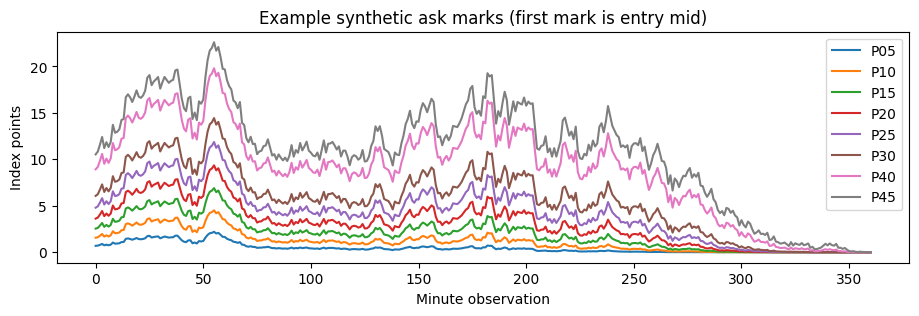

In [3]:
def black_scholes_put(spot, strike, rate, maturity, iv):
    """Price and long-option Greeks, with decimal IV and positive time."""
    root = np.sqrt(maturity)
    d1 = (np.log(spot/strike) + (rate + .5*iv**2)*maturity)/(iv*root)
    d2 = d1-iv*root
    density = np.exp(-.5*d1**2)/np.sqrt(2*np.pi)
    discount = np.exp(-rate*maturity)
    price = strike*discount*ndtr(-d2)-spot*ndtr(-d1)
    delta = ndtr(d1)-1
    gamma = density/(spot*iv*root)
    theta = -spot*density*iv/(2*root)+rate*strike*discount*ndtr(-d2)
    vega = spot*density*root
    return price, delta, gamma, theta, vega


records = []
example_marks = None
for t, date in enumerate(dates):
    if date not in eligible:
        continue
    spot, rate = market.loc[date, ['entry', 'effr']]
    maturity = market.at[date, 'remaining_minutes']/(ANN*390)
    atm = surface['1000', 0, 'ATM'].loc[date]
    iv_nodes = [surface['1000', 0, 'P10'].loc[date],
                surface['1000', 0, 'P25'].loc[date], atm]
    iv = np.interp(TARGET_DELTAS, [.10, .25, .50], iv_nodes)
    d1 = ndtri(1-TARGET_DELTAS)
    strikes = spot*np.exp(-d1*iv*np.sqrt(maturity)+(rate+.5*iv**2)*maturity)
    premium, delta, gamma, theta, vega = black_scholes_put(spot, strikes, rate, maturity, iv)
    selected = np.abs(np.abs(delta[:, None])-TARGET_DELTAS[None, :]).argmin(axis=0)
    strikes, iv, premium, delta, gamma, theta, vega = [
        x[selected] for x in [strikes, iv, premium, delta, gamma, theta, vega]]
    spread = premium*.04  # Synthetic observation, not an assumed real spread.
    before_settlement = paths[t][31:-1]
    remaining = np.arange(len(before_settlement), 0, -1)/(ANN*390)
    marks = black_scholes_put(before_settlement[:, None], strikes[None, :], rate,
                              remaining[:, None], iv[None, :])[0]
    ask_marks = marks*1.02
    payoff = np.maximum(strikes-market.at[date, 'close'], 0)
    all_marks = np.vstack([premium, ask_marks, payoff])
    minute_pnl = -np.diff(all_marks, axis=0)
    gross = premium-payoff
    downside = np.sqrt(np.square(np.minimum(minute_pnl, 0)).sum(axis=0))
    z = gross/(downside+1e-8)
    if example_marks is None:
        example_marks = pd.DataFrame(all_marks, columns=CANDIDATES[:-1])
    for j, candidate in enumerate(CANDIDATES[:-1]):
        records.append(dict(date=date, candidate=candidate, spot=spot, strike=strikes[j],
            premium=premium[j], bid=premium[j]-spread[j]/2, ask=premium[j]+spread[j]/2,
            delta=delta[j], gamma=gamma[j], theta=theta[j], vega=vega[j],
            entry_iv=iv[j], target_delta=-TARGET_DELTAS[j], dte=0.,
            payoff=payoff[j], gross=gross[j], downside=downside[j], z=z[j]))
    records.append(dict(date=date, candidate='SKIP', gross=0., z=0., payoff=0.))

panel = pd.DataFrame(records).set_index(['date', 'candidate']).sort_index()
row_dates = panel.index.get_level_values('date')
real = panel.index.get_level_values('candidate') != 'SKIP'
assert panel.groupby(level='date').size().eq(len(CANDIDATES)).all()
assert np.allclose(panel.loc[real, 'gross'],
                   panel.loc[real, 'premium']-panel.loc[real, 'payoff'])
display(panel.loc[eligible[0], ['premium', 'delta', 'gamma', 'gross', 'downside', 'z']])
example_marks.plot(title='Example synthetic ask marks (first mark is entry mid)', figsize=(11, 3))
plt.xlabel('Minute observation'); plt.ylabel('Index points'); plt.show()

## 3. Feature catalog and availability

`catalog` records each feature's scope (**CS**: one value per day; **PS**: one per
candidate), primary group, source groups, and lag. `X` is the actual matrix sent
to selection; identifiers and future outcomes live separately in `panel`.

Compute statistics at observation time, then shift **once**. Products combine
same-observation-date factors **before** their prescribed lag. We do not multiply
an already-shifted VIX by an unshifted Greek and shift it again.

Percentiles compare today's value to the preceding 252 observations, excluding
today. Explicit `_wd_rank` features use within-day ranks; other columns remain
in their defined units. No blanket cross-ranking or scaling is performed.

In [4]:
feature_values, feature_metadata, cs_raw = {}, {}, {}
GROUP_ORDER = ['calendar', 'morning', 'spx', 'vix', 'macro', 'vol_surface',
               'rv_iv', 'higher_moments', 'vix_curvature', 'trend',
               'position', 'strategy_stats', 'liquidity', 'intra_strategy', 'regime']


def ratio(a, b):
    """Undefined ratios become missing, without clipping a finite value."""
    return (a / b.replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)


def percentile(s, window=252):
    """Strict percentile against the preceding window, excluding current."""
    return s.rolling(window+1).apply(lambda a: np.mean(a[:-1] < a[-1]), raw=True)


def add_cs(name, value, group, lag=1, sources=None):
    """Align one daily observation to every candidate, applying its lag once."""
    raw = pd.Series(value, index=dates, dtype=float)
    cs_raw[name] = raw
    feature_values[name] = pd.Series(raw.shift(lag).reindex(row_dates).to_numpy(), index=panel.index)
    feature_metadata[name] = dict(scope='CS', group=group, lag=lag, sources=set(sources or [group]))


def add_ps(name, value, group, lag=0, sources=None):
    """Align candidate observations and optionally shift within each bucket."""
    value = value.reindex(panel.index).astype(float)
    if lag:
        value = value.groupby(level='candidate').shift(lag)
    feature_values[name] = value.replace([np.inf, -np.inf], np.nan)
    feature_metadata[name] = dict(scope='PS', group=group, lag=lag, sources=set(sources or [group]))


def cs_on_rows(s):
    return pd.Series(s.reindex(row_dates).to_numpy(), index=panel.index)


def event_distance(event):
    positions = dates.get_indexer(events[event])
    ix = np.arange(n_days)
    before = np.searchsorted(positions, ix, side='right')-1
    after = np.searchsorted(positions, ix, side='left')
    since = np.where(before >= 0, ix-positions[np.maximum(before, 0)], np.nan)
    until = np.where(after < len(positions), positions[np.minimum(after, len(positions)-1)]-ix, np.nan)
    return since, until


add_cs('day_of_week', dates.weekday+1, 'calendar', 0)
add_cs('day_of_month', dates.day, 'calendar', 0)
add_cs('month_of_year', dates.month, 'calendar', 0)
opex = (dates.weekday == 4) & (dates.day >= 15) & (dates.day <= 21)
add_cs('is_monthly_opex', opex, 'calendar', 0)
add_cs('is_quarterly_opex', opex & dates.month.isin([3, 6, 9, 12]), 'calendar', 0)
business = pd.bdate_range(dates[0], dates[-1])
holidays = business.difference(dates)
add_cs('is_post_holiday_session', [any((h < d) and (h > (dates[i-1] if i else d))
                                     for h in holidays) for i, d in enumerate(dates)], 'calendar', 0)
add_cs('is_pre_holiday_session', [any((h > d) and (h < (dates[i+1] if i+1 < n_days else d))
                                    for h in holidays) for i, d in enumerate(dates)], 'calendar', 0)
for event in events:
    since, until = event_distance(event)
    add_cs(f'days_until_next_{event}', until, 'calendar', 0)
    if event == 'fomc':
        add_cs('days_since_last_fomc', since, 'calendar', 0)
    else:
        add_cs(f'is_{event}_day', dates.isin(events[event]), 'calendar', 0)

o, e, p = market.open, market.entry, market.close
h, low = market.morning_high, market.morning_low
add_cs('morning_spx_log_return', np.log(e/o), 'morning', 0)
add_cs('morning_spx_range_pct', (h-low)/o, 'morning', 0)
add_cs('morning_spx_directionality', ratio(e-o, h-low).where(h != low, 0), 'morning', 0)
add_cs('morning_gap_size', (o-p.shift())/p.shift(), 'morning', 0)
add_cs('morning_gap_filled', (low <= p.shift()) & (p.shift() <= h), 'morning', 0)
add_cs('morning_spx_rv_annualized', np.sqrt(ANN*390*market.morning_sumsq), 'morning', 0)
iv_morning = surface['1000', 1, 'ATM']-surface['0935', 1, 'ATM']
add_cs('morning_atmf_iv_change', iv_morning, 'morning', 0, ['morning', 'vol_surface'])
add_cs('morning_atmf_iv_pct_change', iv_morning/surface['0935', 1, 'ATM'], 'morning', 0,
       ['morning', 'vol_surface'])
skew_morning = ((surface['1000', 1, 'C25']-surface['1000', 1, 'P25'])-
                (surface['0935', 1, 'C25']-surface['0935', 1, 'P25']))
add_cs('morning_skew_change', skew_morning, 'morning', 0, ['morning', 'vol_surface'])
add_cs('morning_vix_level', market.VIX, 'morning', 1, ['morning', 'vix'])
for name in ['VIX', 'VVIX']:
    add_cs(f'morning_{name.lower()}_change', market[name].diff(), 'morning', 1, ['morning', 'vix'])

log_returns = np.log(p).diff()
rv = {n: np.sqrt(ANN*log_returns.pow(2).rolling(n).mean()) for n in [5, 21, 63, 252]}
# Reconstruction: 1m/3m/6m/1y mean 21/63/126/252 sessions.
for suffix, n in [('1d', 1), ('5d', 5), ('10d', 10), ('1m', 21), ('3m', 63), ('6m', 126), ('1y', 252)]:
    add_cs(f'spx_{suffix}_returns', p.pct_change(n), 'spx')
for n, value in rv.items():
    add_cs(f'spx_{n}d_rv', value, 'spx')
add_cs('spx_returns_roll_avg_30d', daily_return.rolling(30).mean(), 'spx')
add_cs('spx_returns_roll_std_30d', daily_return.rolling(30).std(), 'spx')
add_cs('spx_1y_percentile', percentile(p), 'spx')
add_cs('spx_position_52w', ratio(p-p.rolling(252).min(), p.rolling(252).max()-p.rolling(252).min()), 'spx')
for prefix in ['spx', 'vix']:
    s = market[f'{prefix}_pcr']
    add_cs(f'{prefix}_put_call_ratio', s, 'spx')
    add_cs(f'{prefix}_pcr_21d_avg', s.rolling(21).mean(), 'spx')
    for n in [5, 21]:
        add_cs(f'{prefix}_pcr_{n}d_pct_change', s.pct_change(n), 'spx')

for name in ['VIX', 'VIX1D', 'VIX9D', 'VIX3M', 'VIX6M', 'VVIX']:
    add_cs(name, market[name], 'vix')
for name in ['VIX1D', 'VIX9D', 'VIX3M', 'VIX6M']:
    add_cs(f'VIX_{name}_ratio', market.VIX/market[name], 'vix')
    add_cs(f'VIX_{name}_spread', market.VIX-market[name], 'vix')
for name in ['VIX', 'VIX1D', 'VVIX']:
    for n in [5, 21]:
        add_cs(f'{name}_{n}d_pct_change', market[name].pct_change(n), 'vix')
    add_cs(f'{name}_1y_percentile', percentile(market[name]), 'vix')
for name, value in [('vix_futures_front_price', market.M1), ('vix_front_slope', market.M2-market.M1),
                    ('vix_front_curvature', 2*market.M2-market.M1-market.M3),
                    ('front_roll_yield', (market.M2-market.M1)/market.D1),
                    ('vix_z_60d', ratio(market.VIX-market.VIX.rolling(60).mean(), market.VIX.rolling(60).std()))]:
    add_cs(name, value, 'vix')
for name, s in [('effr_rate', market.effr), ('jobless_claims', market.claims)]:
    add_cs(name, s, 'macro')
    add_cs(f'{name}_1y_pct_change', s.pct_change(252, fill_method=None), 'macro')
    add_cs(f'{name}_1y_percentile', percentile(s), 'macro')

In [5]:
for tenor in [1, 5, 20, 30, 60, 90]:
    add_cs(f'atmf_iv_{tenor}dte_close', surface['close', tenor, 'ATM'], 'vol_surface')
for tenor in [1, 5]:
    add_cs(f'atmf_iv_{tenor}dte_1000', surface['1000', tenor, 'ATM'], 'vol_surface', 0)
for tenor in [5, 30]:
    for side, label in [('P', 'put'), ('C', 'call')]:
        add_cs(f'{label}_25d_iv_{tenor}dte_close', surface['close', tenor, f'{side}25'], 'vol_surface')
for tenor in [1, 5, 30]:
    add_cs(f'atmf_iv_{tenor}dte_percentile_252d', percentile(surface['close', tenor, 'ATM']), 'vol_surface')
for delta, grid in [(25, [1, 5, 10, 20, 30]), (10, [0, 1, 5, 10, 20, 30])]:
    for tenor in grid:
        add_cs(f'risk_reversal_delta{delta}_{tenor}dte_close',
               surface['close', tenor, f'C{delta}']-surface['close', tenor, f'P{delta}'], 'vol_surface')
for side, label, grid in [('P', 'put', [1, 5, 20, 30]), ('C', 'call', [1, 5, 20])]:
    for tenor in grid:
        atm = surface['close', tenor, 'ATM']
        add_cs(f'{label}_skew_delta25_{tenor}dte_close', (atm-surface['close', tenor, f'{side}25'])/atm, 'vol_surface')
for kind, label, pairs in [('ATM', 'atmf', [(5,10), (5,30), (10,20), (20,30), (30,60)]),
                            ('P25', 'put_25d', [(5,30), (10,20)])]:
    for a, b in pairs:
        variance = (surface['close', b, kind]**2*b-surface['close', a, kind]**2*a)/(b-a)
        # Source leaves negative forward variance undefined: keep missing, not zero.
        add_cs(f'{label}_forward_vol_{a}d_{b}d_close', np.sqrt(variance.where(variance >= 0)), 'vol_surface')
mean_iv = surface['close', 5, 'ATM'].rolling(5).mean()
add_cs('rv_surprise_5d', (rv[5]-mean_iv)/mean_iv, 'vol_surface', 1, ['vol_surface', 'spx'])
for tenor in [0, 1, 5, 10, 20, 30]:
    add_cs(f'iv_to_spot_change_ratio_{tenor}dte_close',
           ratio(surface['close', tenor, 'ATM'].pct_change(), daily_return), 'vol_surface')
for tenor in [0, 10, 30]:
    snapshots = pd.concat([surface[s, tenor, 'ATM'] for s in ['0935', '1000', 'close']], axis=1)
    add_cs(f'atmf_iv_{tenor}dte_intraday_pct_change', snapshots.iloc[:, -1]/snapshots.iloc[:, 0]-1, 'vol_surface')
    add_cs(f'atmf_iv_{tenor}dte_intraday_range', snapshots.max(axis=1)-snapshots.min(axis=1), 'vol_surface')

for n, tenor in [(5, 5), (21, 20)]:
    atm = surface['close', tenor, 'ATM']
    add_cs(f'rv_iv_spread_{n}d', rv[n]-atm, 'rv_iv', 1, ['rv_iv', 'spx', 'vol_surface'])
    add_cs(f'rv_iv_ratio_{n}d', rv[n]/atm, 'rv_iv', 1, ['rv_iv', 'spx', 'vol_surface'])
iv_slope = surface['close', 30, 'ATM']-surface['close', 5, 'ATM']
rv_slope = rv[21]-rv[5]
add_cs('iv_term_slope_5d_30d', iv_slope, 'rv_iv', 1, ['rv_iv', 'vol_surface'])
add_cs('rv_term_slope_5d_21d', rv_slope, 'rv_iv', 1, ['rv_iv', 'spx'])
add_cs('iv_minus_rv_term_slope', iv_slope-rv_slope, 'rv_iv', 1, ['rv_iv', 'spx', 'vol_surface'])
for n in [21, 63]:
    add_cs(f'spx_realized_skew_{n}d', log_returns.rolling(n).skew(), 'higher_moments')
    add_cs(f'spx_realized_kurtosis_{n}d', log_returns.rolling(n).kurt(), 'higher_moments')
for name, value in [('9d_30d_3m', market.VIX9D-2*market.VIX+market.VIX3M),
                    ('1d_9d_30d', market.VIX1D-2*market.VIX9D+market.VIX),
                    ('1d_30d_3m', market.VIX1D-2*market.VIX+market.VIX3M)]:
    add_cs(f'vix_curvature_{name}', value, 'vix_curvature', 1, ['vix_curvature', 'vix'])
ma50, ma200 = p.rolling(50).mean(), p.rolling(200).mean()
add_cs('spx_distance_from_50dma_pct', (p-ma50)/ma50, 'trend')
add_cs('spx_distance_from_200dma_pct', (p-ma200)/ma200, 'trend')
add_cs('spx_50_200_dma_signal', np.sign(ma50-ma200), 'trend')
add_cs('spx_200dma_slope_21d_pct', ma200.pct_change(21, fill_method=None), 'trend')

In [6]:
for name in ['delta', 'gamma', 'theta', 'vega']:
    add_ps(name, panel[name], 'position')
add_ps('dollar_delta', 100*panel.delta.abs(), 'position')
add_ps('gamma_exposure', -100*panel.gamma.abs()*panel.spot, 'position')
add_ps('log_moneyness', np.log(panel.strike/panel.spot), 'position')
add_ps('leverage', (panel.spot*panel.delta/panel.premium).abs(), 'position')
gap = panel.entry_iv-cs_on_rows(surface['1000', 0, 'ATM'])
add_ps('delta_distance_from_target', panel.delta-panel.target_delta, 'intra_strategy')
add_ps('iv_at_strike_minus_atmf', gap, 'intra_strategy')
add_ps('iv_at_strike_minus_atmf_pct', gap/cs_on_rows(surface['1000', 0, 'ATM']), 'intra_strategy')
add_ps('dte_of_selected_option', panel.dte, 'intra_strategy')
add_ps('entry_bid_ask_spread', panel.ask-panel.bid, 'liquidity')
add_ps('entry_bid_ask_spread_pct', (panel.ask-panel.bid)/panel.premium, 'liquidity')
add_ps('entry_log_premium', np.log(panel.premium), 'liquidity')


def ps_rolling(s, window, method, *args, **kwargs):
    return s.groupby(level='candidate', group_keys=False).transform(
        lambda part: getattr(part.rolling(window), method)(*args, **kwargs))


rom = ratio(panel.gross, panel.premium).where(real, 0.)
stats_raw = {'returns_on_margin': rom,
             'rom_diff_to_spx': rom-cs_on_rows(daily_return)}
for suffix, method in [('avg', 'mean'), ('std', 'std'), ('skew', 'skew')]:
    stats_raw[f'rom_roll_{suffix}_30d'] = ps_rolling(rom, 30, method)
sharpe60 = ratio(ps_rolling(rom, 60, 'mean'), ps_rolling(rom, 60, 'std'))
stats_raw['sharpe_ratio_rom_60d'] = sharpe60
stats_raw['sharpe_ratio_rom_std_60d'] = ps_rolling(sharpe60, 60, 'std')
stats_raw['win_rate_30d'] = ps_rolling((rom > 0).where(rom.notna()).astype(float), 30, 'mean')
# Cumulative dollar P&L starts at the first synthetic warm-up observation.
cumulative = (100*panel.gross).groupby(level='candidate').cumsum()
for n in [5, 63, 126, 252]:
    peak = ps_rolling(cumulative, n, 'max')
    drawdown = ratio(peak-cumulative, peak)
    if n == 5:
        stats_raw['prior_day_strategy_drawdown_max_5d'] = drawdown
    else:
        stats_raw[f'drawdown_{n}'] = drawdown
        stats_raw[f'distance_from_max_{n}'] = cumulative-peak
time_index = np.arange(1, 61)
stats_raw['stability_coef_60d'] = ps_rolling(rom, 60, 'apply',
    lambda a: np.corrcoef(a, time_index)[0, 1]**2 if np.std(a) > 0 else np.nan, raw=True)
stats_raw['tail_ratio_rom_30d'] = ratio(ps_rolling(rom, 30, 'quantile', .95).abs(),
                                      ps_rolling(rom, 30, 'quantile', .05).abs())
for name, value in stats_raw.items():
    add_ps(name, value.where(real), 'strategy_stats', lag=1)
# Explicit source exception: SKIP's ROM is zero; its other PS statistics are missing.
feature_values['returns_on_margin'].loc[~real] = 0.

rank_sources = {
    'iv_at_strike_minus_atmf': 'iv_at_strike_minus_atmf',
    'returns_on_margin': 'returns_on_margin',
    'sharpe_ratio_rom_60d': 'sharpe_ratio_rom_60d',
    'drawdown_63d': 'drawdown_63',  # Explicit resolution of the source spelling conflict.
    'entry_bid_ask_spread_pct': 'entry_bid_ask_spread_pct',
    'entry_log_premium': 'entry_log_premium',
}
for output, source in rank_sources.items():
    values = feature_values[source].where(real).groupby(level='date').rank(ascending=False, method='average')
    values.loc[~real] = len(TARGET_DELTAS)+.5
    info = feature_metadata[source]
    add_ps(f'{output}_wd_rank', values, info['group'], sources=info['sources'])
    feature_metadata[f'{output}_wd_rank']['lag'] = info['lag']  # Already applied to its source.

products = {
    'delta_x_VIX': ('delta', 'VIX'),
    'gamma_x_morning_spx_rv_annualized': ('gamma', 'morning_spx_rv_annualized'),
    'vega_x_VIX_5d_pct_change': ('vega', 'VIX_5d_pct_change'),
    'iv_at_strike_minus_atmf_x_VIX_VIX9D_spread': ('iv_at_strike_minus_atmf', 'VIX_VIX9D_spread'),
    'theta_x_atmf_iv_5dte_percentile_252d': ('theta', 'atmf_iv_5dte_percentile_252d'),
    'delta_distance_from_target_x_VVIX_1y_percentile': ('delta_distance_from_target', 'VVIX_1y_percentile'),
    'gamma_x_dte': ('gamma', 'dte_of_selected_option'),
}
for name, (a, b) in products.items():
    a_value = feature_values[a]  # These candidate sources are all unlagged.
    b_value = cs_on_rows(cs_raw[b]) if b in cs_raw else feature_values[b]
    sources = {'regime'} | feature_metadata[a]['sources'] | feature_metadata[b]['sources']
    add_ps(name, a_value*b_value, 'regime', lag=1, sources=sources)

X = pd.DataFrame(feature_values).replace([np.inf, -np.inf], np.nan)
catalog = pd.DataFrame.from_dict(feature_metadata, orient='index').rename_axis('feature')
display(catalog.groupby(['scope', 'group'], sort=False).size().rename('candidate features').to_frame())
display(catalog.loc[list(products)])
print(f'{X.shape[1]} disclosed feature expansions; {len(X):,} candidate rows.')
print('Synthetic constant features (e.g. same-session DTE) will be screened by S2.')
display(X.loc[eligible[-1], ['delta', 'VIX', 'delta_x_VIX', 'entry_log_premium',
                            'entry_log_premium_wd_rank']])

candidate features
scope group                             
CS    calendar                        15
      morning                         12
      spx                             23
      vix                             28
      macro                            6
      vol_surface                     53
      rv_iv                            7
      higher_moments                   4
      vix_curvature                    3
      trend                            4
PS    position                         8
      intra_strategy                   5
      liquidity                        5
      strategy_stats                  20
      regime                           7

,scope,group,lag,sources
feature,,,,
delta_x_VIX,PS,regime,1,"{position, regime, vix}"
gamma_x_morning_spx_rv_annualized,PS,regime,1,"{position, morning, regime}"
vega_x_VIX_5d_pct_change,PS,regime,1,"{position, regime, vix}"
iv_at_strike_minus_atmf_x_VIX_VIX9D_spread,PS,regime,1,"{regime, intra_strategy, vix}"
theta_x_atmf_iv_5dte_percentile_252d,PS,regime,1,"{position, regime, vol_surface}"
delta_distance_from_target_x_VVIX_1y_percentile,PS,regime,1,"{regime, intra_strategy, vix}"
gamma_x_dte,PS,regime,1,"{position, regime, intra_strategy}"


200 disclosed feature expansions; 19,386 candidate rows.
Synthetic constant features (e.g. same-session DTE) will be screened by S2.


,delta,VIX,delta_x_VIX,entry_log_premium,entry_log_premium_wd_rank
candidate,,,,,
P05,-0.05,27.108245,-1.355412,-0.622469,8.0
P10,-0.10,27.108245,-2.710824,0.196166,7.0
P15,-0.15,27.108245,-4.066237,0.686878,6.0
P20,-0.20,27.108245,-5.421649,1.044631,5.0
P25,-0.25,27.108245,-6.777061,1.329562,4.0
P30,-0.30,27.108245,-8.132473,1.568835,3.0
P40,-0.40,27.108245,-10.843298,1.962800,2.0
P45,-0.45,27.108245,-12.198710,2.132244,1.0
SKIP,NaN,27.108245,NaN,NaN,8.5


## 4. Training dates and frozen grades

For prediction year $Y$, the full history ends before January 1 of $Y$.
Reserve its last six months for the gate. The preceding six months are the
hyperparameter validation slice; its final three months provide early stopping.
The final refit uses all pre-gate observations except those final three months.
2025 is held out from every model/threshold/size choice.

The score $z$ is converted to grades 0–4 using pooled **non-SKIP training**
quantiles at 10%, 40%, 60%, 90%. These are absolute pooled thresholds, not
within-day quantiles. SKIP's grade is whichever interval contains zero.

The source feature-selection window includes tuning/early-stop dates. Therefore
the tuning metric is not an unbiased evaluation of the entire selection
pipeline. Future prediction years, however, remain outside feature selection.

In [7]:
def date_roles(year, history_start='2018-01-01'):
    boundary = pd.Timestamp(year=year, month=1, day=1)
    gate_start = boundary-pd.DateOffset(months=6)
    tune_start = gate_start-pd.DateOffset(months=6)
    stop_start = gate_start-pd.DateOffset(months=3)
    start = pd.Timestamp(history_start)
    return dict(start=start, tune_start=tune_start, stop_start=stop_start,
                gate_start=gate_start, prediction_start=boundary,
                prediction_end=boundary+pd.DateOffset(years=1))


def period_mask(start, end):
    return (row_dates >= start) & (row_dates < end)


def grade_cuts(mask):
    return panel.loc[mask & real, 'z'].quantile(GRADE_QUANTILES, interpolation='linear').to_numpy()


def grades(z, cuts):
    return np.searchsorted(cuts, np.asarray(z), side='left').astype(np.int32)


timeline = pd.DataFrame({y: date_roles(y) for y in PREDICTION_YEARS}).T
display(timeline)
example_roles = date_roles(2021)
example_cuts = grade_cuts(period_mask(example_roles['start'], example_roles['tune_start']))
display(pd.Series(example_cuts, index=GRADE_QUANTILES, name='2021 search-fit z thresholds'))
print('2021 search-fit SKIP grade:', grades([0.], example_cuts)[0], '(not hard-coded)')

,start,tune_start,stop_start,gate_start,prediction_start,prediction_end
2021,2018-01-01,2020-01-01,2020-04-01,2020-07-01,2021-01-01,2022-01-01
2022,2018-01-01,2021-01-01,2021-04-01,2021-07-01,2022-01-01,2023-01-01
2023,2018-01-01,2022-01-01,2022-04-01,2022-07-01,2023-01-01,2024-01-01
2024,2018-01-01,2023-01-01,2023-04-01,2023-07-01,2024-01-01,2025-01-01
2025,2018-01-01,2024-01-01,2024-04-01,2024-07-01,2025-01-01,2026-01-01


0.1   -0.670570
0.4    0.931724
0.6    1.384942
0.9    2.773781
Name: 2021 search-fit z thresholds, dtype: float64

2021 search-fit SKIP grade: 1 (not hard-coded)


## 5. S1–S5 feature selection

Apply the source thresholds in order. S3 is a **screen**, not a transformation
of the features fed to LightGBM. CS relevance is cross-day Spearman correlation
with the day-mean label. PS relevance is the median of within-day Spearman
correlations. SKIP is excluded from selection statistics.

S4 clusters only within the same scope at $|\rho|\ge0.85$. A graph connected
component is our explicit choice for the source's unspecified clustering rule.
Keep the strongest representative and apply source group caps. S5 reruns these
steps on three expanding prefixes and requires survival in at least two folds.
The final set also passes S1–S4 on the complete pre-gate selection window.

Every dropped column has a recorded reason; the notebook does not force the
synthetic feature count to match the paper's reported 50–60 survivors.

In [8]:
def relevance(frame, target, columns):
    result = pd.Series(np.nan, index=columns, dtype=float)
    cs = [c for c in columns if catalog.at[c, 'scope'] == 'CS']
    ps = [c for c in columns if catalog.at[c, 'scope'] == 'PS']
    day_target = target.groupby(level='date').mean()
    if cs:
        daily = frame[cs].groupby(level='date').first()
        result.loc[cs] = daily.corrwith(day_target, method='spearman')
    if ps:
        # Pairwise-complete Spearman per feature/day; missingness changes y ranks.
        correlations = {}
        for c in ps:
            valid = frame[c].notna() & target.notna()
            pair = pd.DataFrame({'x': frame.loc[valid, c], 'y': target.loc[valid]})
            ranked = pair.groupby(level='date').rank(method='average')
            centered = ranked-ranked.groupby(level='date').transform('mean')
            numerator = (centered.x*centered.y).groupby(level='date').sum()
            denominator = np.sqrt(centered.x.pow(2).groupby(level='date').sum()*
                                  centered.y.pow(2).groupby(level='date').sum())
            correlations[c] = ratio(numerator, denominator).median()
        result.loc[ps] = pd.Series(correlations)
    return result


def select_s1_s4(mask, columns, correlation_threshold=.85):
    frame = X.loc[mask & real, columns]
    target = panel.loc[frame.index, 'z']
    audit = pd.DataFrame(index=columns)
    audit['null_rate'] = frame.isna().mean()
    audit['variance'] = frame.var()
    audit['modal_fraction'] = frame.apply(lambda s: s.value_counts(normalize=True).max())
    audit['reason'] = 'kept'
    audit.loc[audit.null_rate > .30, 'reason'] = 'S1 missingness'
    s2 = (audit.variance < 1e-6) | (audit.modal_fraction > .99)
    audit.loc[(audit.reason == 'kept') & s2, 'reason'] = 'S2 near-constant'
    candidates = audit.index[audit.reason == 'kept'].tolist()
    audit['relevance'] = relevance(frame, target, candidates)
    weak = audit.relevance.isna() | (audit.relevance.abs() < .05)
    audit.loc[(audit.reason == 'kept') & weak, 'reason'] = 'S3 relevance'

    def priority(c):
        return (-abs(audit.at[c, 'relevance']), GROUP_ORDER.index(catalog.at[c, 'group']),
                audit.at[c, 'null_rate'], c)

    for scope in ['CS', 'PS']:
        columns_scope = [c for c in audit.index[audit.reason == 'kept'] if catalog.at[c, 'scope'] == scope]
        if not columns_scope:
            continue
        data = frame[columns_scope]
        if scope == 'CS':
            data = data.groupby(level='date').first()
        corr = data.corr(method='spearman').abs().fillna(0)
        adjacency = corr.to_numpy() >= correlation_threshold
        np.fill_diagonal(adjacency, True)
        _, components = connected_components(csr_matrix(adjacency), directed=False)
        for component in np.unique(components):
            members = [c for c, label in zip(columns_scope, components) if label == component]
            winner = min(members, key=priority)
            for c in members:
                if c != winner:
                    audit.at[c, 'reason'] = 'S4 redundancy'
    caps = {'position': 8, 'vol_surface': 4, 'vix': 6, 'calendar': 8}
    for group in GROUP_ORDER:
        members = [c for c in audit.index[audit.reason == 'kept'] if catalog.at[c, 'group'] == group]
        for c in sorted(members, key=priority)[caps.get(group, 5):]:
            audit.at[c, 'reason'] = 'S4 group cap'
    return audit.index[audit.reason == 'kept'].tolist(), audit


def select_features(mask, drop_groups=(), drop_features=(), correlation_threshold=.85):
    columns = [c for c in X if c not in drop_features and
               not (catalog.at[c, 'sources'] & set(drop_groups))]
    selected, audit = select_s1_s4(mask, columns, correlation_threshold)
    training_dates = row_dates[mask].unique().sort_values()
    folds = np.array_split(training_dates, 3)  # Three equal date partitions; source leaves endpoints open.
    survivors = Counter()
    for fold in folds:
        fold_mask = mask & (row_dates <= fold[-1])
        fold_features, _ = select_s1_s4(fold_mask, columns, correlation_threshold)
        survivors.update(fold_features)
    audit['fold_survival'] = pd.Series(survivors).reindex(audit.index, fill_value=0)
    audit.loc[(audit.reason == 'kept') & (audit.fold_survival < 2), 'reason'] = 'S5 unstable'
    final = audit.index[audit.reason == 'kept'].tolist()
    if not final:
        raise ValueError('No features survive: inspect synthetic data and selection audit; do not bypass S1–S5.')
    return final, audit


first_selection_mask = period_mask(example_roles['start'], example_roles['gate_start'])
first_features, first_audit = select_features(first_selection_mask)
display(first_audit.groupby('reason', sort=False).size().rename('features').to_frame())
display(first_audit.loc[first_features].join(catalog[['scope', 'group']]))

,features
reason,
S3 relevance,104
kept,27
S5 unstable,7
S4 redundancy,47
S2 near-constant,7
S4 group cap,8


,null_rate,variance,modal_fraction,reason,relevance,fold_survival,scope,group
month_of_year,0.000000,1.138015e+01,0.102007,kept,-0.057821,2,CS,calendar
is_monthly_opex,0.000000,3.076951e-02,0.968227,kept,-0.072710,3,CS,calendar
is_quarterly_opex,0.000000,9.934851e-03,0.989967,kept,-0.091851,2,CS,calendar
is_post_holiday_session,0.000000,3.544325e-02,0.963211,kept,0.102817,3,CS,calendar
days_until_next_pce,0.000000,3.681432e+01,0.050167,kept,-0.073349,3,CS,calendar
morning_gap_size,0.000000,9.910203e-06,0.001672,kept,-0.060828,3,CS,morning
morning_vix_change,0.000000,1.180443e+01,0.001672,kept,0.067377,3,CS,morning
morning_vvix_change,0.000000,6.305665e+01,0.001672,kept,0.087519,2,CS,morning
spx_252d_rv,0.003344,8.595093e-04,0.001678,kept,0.052711,2,CS,spx
vix_put_call_ratio,0.000000,4.794219e-02,0.001672,kept,-0.050221,3,CS,spx


## 6. LambdaRank model calibration

LightGBM receives one query group per date, nine contiguous rows per group, and
the selected numeric columns. It learns one shared score function for all
candidates. There is no structure-name feature or candidate-specific model.

Use `lambdarank`, gains `[0,1,3,7,15]`, NDCG@1/@3, truncation 5. Each window runs
50 TPE trials over the published ranges. We interpret the ambiguous two
subsampling entries as column (`feature_fraction`) and row (`bagging_fraction`)
sampling. The last three tuning months drive early stopping at patience 50;
the complete six-month tuning slice supplies the trial's NDCG@1 objective.
The winning configuration is refitted, with a distinct threshold fit on the
refit fitting dates and the recent three months again used for early stopping.

Technical references: [LightGBM training](https://lightgbm.readthedocs.io/en/stable/pythonapi/lightgbm.train.html),
[early stopping](https://lightgbm.readthedocs.io/en/stable/pythonapi/lightgbm.early_stopping.html),
[Optuna TPE](https://optuna.readthedocs.io/en/stable/reference/samplers/generated/optuna.samplers.TPESampler.html).

In [9]:
BASE_PARAMS = dict(objective='lambdarank', metric='ndcg', ndcg_eval_at=[1, 3],
    label_gain=GAIN.tolist(), lambdarank_truncation_level=5,
    verbosity=-1, deterministic=True, force_col_wise=True, feature_pre_filter=False,
    num_threads=int(os.environ.get('OMP_NUM_THREADS', 0)))


def make_dataset(mask, features, cuts, reference=None):
    frame = X.loc[mask, features]
    group = frame.groupby(level='date', sort=False).size().to_numpy()
    assert group.sum() == len(frame)
    assert frame.index.is_monotonic_increasing
    return lgb.Dataset(frame.to_numpy(), label=grades(panel.loc[mask, 'z'], cuts),
                       group=group, feature_name=features, reference=reference,
                       free_raw_data=False, params={'feature_pre_filter': False})


def ndcg_at(mask, predictions, cuts, k=1):
    """Macro-average per-date NDCG using the source gain vector; ties are stable."""
    labels = grades(panel.loc[mask, 'z'], cuts)
    frame = pd.DataFrame({'gain': GAIN[labels], 'score': predictions}, index=panel.index[mask])
    values = []
    for _, group in frame.groupby(level='date', sort=False):
        discount = np.log2(np.arange(2, min(k, len(group))+2))
        actual = group.sort_values('score', ascending=False, kind='stable').gain.to_numpy()[:k]
        ideal = np.sort(group.gain.to_numpy())[::-1][:k]
        ideal_dcg = np.sum(ideal/discount)
        values.append(np.sum(actual/discount)/ideal_dcg if ideal_dcg else 1.)
    return float(np.mean(values))


def fit_ranker(year, features, roles, trials=PAPER_TRIALS):
    search_fit = period_mask(roles['start'], roles['tune_start'])
    search_validation = period_mask(roles['tune_start'], roles['gate_start'])
    early_stop = period_mask(roles['stop_start'], roles['gate_start'])
    search_cuts = grade_cuts(search_fit)
    train_set = make_dataset(search_fit, features, search_cuts)
    stop_set = make_dataset(early_stop, features, search_cuts, train_set)

    def objective(trial):
        params = dict(BASE_PARAMS, seed=SEED+year,
            num_leaves=trial.suggest_int('num_leaves', 16, 256, log=True),
            learning_rate=trial.suggest_float('learning_rate', .01, .10, log=True),
            min_data_in_leaf=trial.suggest_int('min_data_in_leaf', 20, 200, log=True),
            feature_fraction=trial.suggest_float('feature_fraction', .5, 1.),
            bagging_fraction=trial.suggest_float('bagging_fraction', .5, 1.),
            bagging_freq=trial.suggest_int('bagging_freq', 0, 10),
            lambda_l1=trial.suggest_float('lambda_l1', 1e-3, 10., log=True),
            lambda_l2=trial.suggest_float('lambda_l2', 1e-3, 10., log=True))
        model = lgb.train(params, train_set, num_boost_round=PAPER_ROUNDS,
            valid_sets=[stop_set], valid_names=['early_stop'],
            callbacks=[lgb.early_stopping(PAPER_PATIENCE, first_metric_only=True, verbose=False)])
        prediction = model.predict(X.loc[search_validation, features].to_numpy())
        trial.set_user_attr('best_iteration', model.best_iteration)
        return ndcg_at(search_validation, prediction, search_cuts)

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED+year))
    study.optimize(objective, n_trials=trials)
    refit_fit = period_mask(roles['start'], roles['stop_start'])
    refit_cuts = grade_cuts(refit_fit)
    train_set = make_dataset(refit_fit, features, refit_cuts)
    stop_set = make_dataset(early_stop, features, refit_cuts, train_set)
    params = dict(BASE_PARAMS, seed=SEED+year, **study.best_params)
    model = lgb.train(params, train_set, num_boost_round=PAPER_ROUNDS,
        valid_sets=[stop_set], valid_names=['early_stop'],
        callbacks=[lgb.early_stopping(PAPER_PATIENCE, first_metric_only=True, verbose=False)])
    return dict(model=model, study=study, cuts=refit_cuts, features=features,
                roles=roles, refit_fit=refit_fit, params=params)


def score_candidates(fitted, mask):
    score = fitted['model'].predict(X.loc[mask, fitted['features']].to_numpy())
    rows = panel.loc[mask].copy()
    rows['score'] = score
    # Candidate name is only a deterministic tie-break outside the model.
    ranked = rows.reset_index().sort_values(['date', 'score', 'candidate'],
                                           ascending=[True, False, True], kind='stable')
    groups = ranked.groupby('date', sort=False)
    top = groups.head(1).set_index('date')
    runner_up = groups.nth(1).set_index('date')
    top['gap'] = top.score-runner_up.score.reindex(top.index)
    assert (top.gap >= 0).all()
    return top

## 7. Confidence gate and the three meanings of calibration

These are separate optimizations:

| Calibration | Criterion | Data |
|---|---|---|
| Ranker hyperparameters | Maximize NDCG@1 | Six pre-gate validation months |
| Confidence threshold | Maximize Sortino of gated top-one P&L | Reserved gate hold-out; archived WF union for 2025 |
| Position-size scalar | Closest training volatility to 16% | Ranker fitting rows, using in-sample predictions |

The confidence variable is the top-one minus top-two score. Trade only if the
winner is real **and** its gap is at least the frozen threshold. SKIP selection
and confidence rejection are different reasons to abstain. All abstention days
remain in return arrays as zeros.

Here the source's unknown gate grid is replaced, with your approval, by all
observed calibration gaps plus zero. Scores are not probabilities. The threshold
does not promise an out-of-sample admission rate.

In [10]:
def entry_fee(quantity, premium):
    unit = np.where(np.asarray(premium) < .05, .25, np.where(np.asarray(premium) < .10, .50, .65))
    return np.where(np.asarray(quantity) > 0, np.maximum(1., np.asarray(quantity)*unit), 0.)


def regt_margin(premium, spot, strike):
    return 100*(premium+np.maximum(.15*spot-np.maximum(0., spot-strike), .10*strike))


def performance(returns):
    r = np.asarray(returns, dtype=float)
    if not len(r) or not np.isfinite(r).all() or np.any(r <= -1):
        raise ValueError('Metrics require finite simple returns above -100%.')
    annual_return = np.expm1(ANN*np.log1p(r).mean())
    vol = np.sqrt(ANN)*r.std(ddof=1) if len(r) > 1 else np.nan
    down = np.sqrt(ANN*np.square(np.minimum(r, 0)).mean())
    wealth = np.r_[1., np.cumprod(1+r)]
    drawdown = 1-wealth/np.maximum.accumulate(wealth)
    sortino = annual_return/down if down > 0 else (np.inf if annual_return > 0 else np.nan)
    return dict(annual_return=annual_return, annual_vol=vol,
                sharpe=annual_return/vol if vol > 0 else np.nan,
                arithmetic_sharpe=ANN*r.mean()/vol if vol > 0 else np.nan,
                sortino=sortino, max_drawdown=drawdown.max())


def calibrate_gate(top):
    real_pick = top.candidate.ne('SKIP').to_numpy()
    unit_net = (100*top.gross.to_numpy()-entry_fee(1, top.premium.to_numpy()))/NAV0
    unit_net = np.where(real_pick, unit_net, 0.)
    thresholds = np.unique(np.r_[0., top.gap.to_numpy()])
    records = []
    for threshold in thresholds:
        admits = top.gap.to_numpy() >= threshold
        gated_returns = np.where(admits & real_pick, unit_net, 0.)
        records.append(dict(threshold=threshold, admission=admits.mean(),
                            trade_rate=(admits & real_pick).mean(),
                            sortino=performance(gated_returns)['sortino']))
    curve = pd.DataFrame(records)
    eligible_curve = curve[curve.sortino.notna()]
    if eligible_curve.empty:
        # No informative return path: threshold zero cannot create an edge.
        # SKIP / zero sizing still prevent trades; record this non-identification.
        curve.attrs['unidentified'] = True
        return 0., curve
    winner = eligible_curve.sort_values(['sortino', 'threshold'], ascending=[False, True]).iloc[0]
    return float(winner.threshold), curve

## 8. All seven sizing methods, collateral and execution

Desired contract counts are rounded **down**, then capped by
$\lfloor NAV_{t-1}/M_t\rfloor$. The Reg-T formula and the premium-dependent fee
schedule are copied from the paper. There is no hedge or exit fee at settlement.

| Method | Desired allocation before the common margin cap |
|---|---|
| FMU | Fixed fraction of NAV divided by per-contract margin |
| VT | Target daily dollar volatility divided by delta-linearized contract volatility |
| SRS | Fixed margin fraction multiplied by bounded relative IV richness |
| EA | Maximum margin fraction multiplied by the training ECDF percentile of IV-minus-RV edge |
| GB | Loss-budget fraction divided by a delta-plus-gamma adverse-move loss |
| HK / QK | Half / quarter of mean-over-variance past return-on-margin, clipped to the calibrated margin fraction |

**Two different ROM definitions:** feature ROM is gross P&L / premium; Kelly
ROM is one-contract net dollar P&L / actual Reg-T margin. Neither uses sized
portfolio P&L as a feature. The distinction is retained despite the source's naming.

All 148 published size-grid values are evaluated per window (740 in total).
The 16% target is a calibration anchor, not a guaranteed achieved volatility.

In [11]:
SIZE_GRIDS = {
    'FMU': np.arange(1, 31)*.02,
    'VT': np.arange(1, 26)*.1,
    'SRS': np.arange(1, 26)*.02,
    'EA': np.arange(1, 17)*.05,
    'GB': np.arange(1, 21)*.005,
    'HK': np.arange(1, 17)*.05,
    'QK': np.arange(1, 17)*.05,
}
assert sum(map(len, SIZE_GRIDS.values())) == 148
margin_all = regt_margin(panel.premium, panel.spot, panel.strike)
kelly_rom = (100*panel.gross-entry_fee(1, panel.premium))/margin_all
kelly_mean = ps_rolling(kelly_rom, 252, 'mean').groupby(level='candidate').shift()
kelly_variance = ps_rolling(kelly_rom, 252, 'var').groupby(level='candidate').shift()
kelly_fraction = ratio(kelly_mean, kelly_variance)
daily_intraday_rv = np.sqrt(market.intraday_sumsq.rolling(5).mean()).shift()


def sizing_inputs(top):
    data = top.copy()
    index = pd.MultiIndex.from_arrays([data.index, data.candidate], names=panel.index.names)
    data['margin'] = regt_margin(data.premium, data.spot, data.strike)
    data['rv_daily'] = daily_intraday_rv.reindex(data.index)
    data['atm_iv'] = surface['1000', 0, 'ATM'].reindex(data.index)
    data['richness'] = data.atm_iv/(market.VIX9D.shift().reindex(data.index)/100)
    data['edge'] = (data.atm_iv-data.rv_daily*np.sqrt(ANN))/(data.rv_daily*np.sqrt(ANN))
    data['kelly'] = kelly_fraction.reindex(index).to_numpy()
    return data


def sizing_constants(training_top):
    data = sizing_inputs(training_top)
    richness = data.richness.dropna()
    median = richness.median()
    normalized_cap = (richness/median).quantile(.95)
    if not median > 0 or not normalized_cap >= 1:
        raise ValueError('Synthetic SRS data violate the chosen normalized-cap interpretation.')
    return dict(richness_median=median, richness_cap=normalized_cap,
                edges=np.sort(data.edge.dropna().to_numpy()),
                adverse=market.adverse_move.reindex(training_top.index).quantile(.95))


def desired_per_nav(data, method, parameter, constants, target_vol=.16):
    """Desired unrounded contracts per dollar of prior NAV."""
    if method == 'FMU':
        coefficient = parameter/data.margin
    elif method == 'VT':
        contract_vol = data.delta.abs()*data.spot*data.rv_daily*100
        coefficient = parameter*target_vol/np.sqrt(ANN)/contract_vol
    elif method == 'SRS':
        scale = (data.richness/constants['richness_median']).clip(lower=1, upper=constants['richness_cap'])
        coefficient = parameter*scale/data.margin
    elif method == 'EA':
        ecdf = np.searchsorted(constants['edges'], data.edge, side='right')/len(constants['edges'])
        coefficient = parameter*ecdf/data.margin
    elif method == 'GB':
        move = constants['adverse']*data.spot
        loss = (data.delta.abs()*move+.5*data.gamma.abs()*move**2)*100
        coefficient = parameter/loss
    elif method in ['HK', 'QK']:
        fraction = (.5 if method == 'HK' else .25)*data.kelly
        coefficient = fraction.clip(lower=0, upper=parameter)/data.margin
    else:
        raise ValueError(method)
    return coefficient


def simulate(top, method, parameter, constants, threshold, initial_nav=NAV0, target_vol=.16):
    data = sizing_inputs(top)
    coefficient = desired_per_nav(data, method, parameter, constants, target_vol)
    admitted = (data.candidate != 'SKIP') & (data.gap >= threshold)
    nav = float(initial_nav)
    ledger = []
    arrays = zip(data.index, data.candidate, admitted, coefficient, data.margin, data.premium,
                 data.gross, data.bid, data.ask, data.payoff)
    for date, candidate, admit, per_nav, margin, premium, gross, bid, ask, payoff in arrays:
        before = nav
        q = 0
        if admit and np.isfinite(per_nav) and per_nav > 0 and np.isfinite(margin) and margin > 0:
            q = min(int(np.floor(before*per_nav)), int(np.floor(before/margin)))
        fee = float(entry_fee(q, premium))
        pnl = 100*q*gross-fee if q else 0.
        nav += pnl
        if nav <= 0:
            raise ValueError('Synthetic portfolio insolvent: do not silently continue negative NAV.')
        ledger.append(dict(date=date, candidate=candidate, quantity=q, margin=margin,
            premium=premium, bid=bid, ask=ask, payoff=payoff, fee=fee, pnl=pnl,
            nav_before=before, nav=nav, returns=pnl/before, admitted=bool(admit)))
    return pd.DataFrame(ledger).set_index('date')


def calibrate_sizes(top, constants, threshold, target_vol=.16, objective='volatility'):
    records, parameters = [], {}
    for method, grid in SIZE_GRIDS.items():
        for parameter in grid:
            ledger = simulate(top, method, parameter, constants, threshold, target_vol=target_vol)
            metrics = performance(ledger.returns)
            if objective == 'volatility':
                score = -abs(metrics['annual_vol']-target_vol)
            elif objective in ['sharpe', 'sortino']:
                score = metrics[objective]
            else:
                raise ValueError(objective)
            records.append(dict(method=method, parameter=parameter, score=score,
                                trades=int((ledger.quantity > 0).sum()), **metrics))
        curve = pd.DataFrame([r for r in records if r['method'] == method])
        valid = curve[curve.score.notna()]
        if valid.empty:
            # All policies make identical no-trade books: smaller grid point wins.
            parameters[method] = float(grid[0])
        else:
            winner = valid.sort_values(['score', 'parameter'], ascending=[False, True]).iloc[0]
            parameters[method] = float(winner.parameter)
    return parameters, pd.DataFrame(records)

## 9. Execute the five annual windows

Feature selection, ranker search/refit, gate calibration and size calibration
are redone at each annual boundary. Prediction years do not feed any fitted
choice. Lagged outcome features and Kelly history may update as outcomes become
available during the year; that is causal feature maintenance, not model refitting.

For 2025, pool archived gate predictions from the 2021–2024 fitting exercises.
Those are predictions on each exercise's own held-out gate dates. Because model
score scales can change, applying a pooled threshold is itself a fragile source
methodology choice, which we preserve and expose.

NAV carries forward between prediction years separately for each sizing method.
The model can change yearly; the portfolio does not restart at $5M each January.

In [12]:
def run_experiment(drop_groups=(), drop_features=(), use_gate=True,
                   correlation_threshold=.85, trials=PAPER_TRIALS,
                   target_vol=.16, size_objective='volatility', history='expanding'):
    fits, yearly_ledgers, gate_archive = {}, {m: [] for m in SIZE_GRIDS}, []
    nav = {m: NAV0 for m in SIZE_GRIDS}
    for year in PREDICTION_YEARS:
        window_started = time.perf_counter()
        start = '2018-01-01'
        if history == 'rolling_3y':
            start = f'{year-3}-01-01'
        elif history == 'initial_2y':
            start = '2019-01-01'  # Same prediction years, expanding from a two-year initial history.
        elif history != 'expanding':
            raise ValueError(history)
        roles = date_roles(year, start)
        selection_mask = period_mask(roles['start'], roles['gate_start'])
        if year == 2021 and not drop_groups and not drop_features and correlation_threshold == .85 and history == 'expanding':
            features, audit = first_features, first_audit
        else:
            features, audit = select_features(selection_mask, drop_groups, drop_features, correlation_threshold)
        fitted = fit_ranker(year, features, roles, trials)
        gate_mask = period_mask(roles['gate_start'], roles['prediction_start'])
        gate_predictions = score_candidates(fitted, gate_mask)
        if year < 2025:
            gate_sample = gate_predictions
            gate_archive.append(gate_predictions)
        else:
            gate_sample = pd.concat(gate_archive).sort_index()
            assert gate_sample.index.is_unique and gate_sample.index.max() < pd.Timestamp('2025-01-01')
        threshold, gate_curve = calibrate_gate(gate_sample)
        if not use_gate:
            threshold = 0.
        training_top = score_candidates(fitted, fitted['refit_fit'])
        constants = sizing_constants(training_top)
        parameters, size_curve = calibrate_sizes(training_top, constants, threshold, target_vol, size_objective)
        prediction_mask = period_mask(roles['prediction_start'], roles['prediction_end'])
        prediction_top = score_candidates(fitted, prediction_mask)
        for method, parameter in parameters.items():
            ledger = simulate(prediction_top, method, parameter, constants, threshold, nav[method], target_vol)
            nav[method] = ledger.nav.iloc[-1]
            yearly_ledgers[method].append(ledger)
        fitted.update(audit=audit, threshold=threshold, gate_curve=gate_curve,
                      gate_sample=gate_sample, training_top=training_top,
                      sizing_constants=constants, sizing_parameters=parameters,
                      size_curve=size_curve, prediction_top=prediction_top)
        fitted['prediction_ndcg1'] = ndcg_at(prediction_mask,
            fitted['model'].predict(X.loc[prediction_mask, features].to_numpy()), fitted['cuts'])
        fits[year] = fitted
        print(f'{year}: {len(features)} features; best tuning NDCG@1={fitted["study"].best_value:.3f}; '
              f'gate={threshold:.4g}; {time.perf_counter()-window_started:.1f}s', flush=True)
    return dict(fits=fits, ledgers={m: pd.concat(parts) for m, parts in yearly_ledgers.items()})


experiment = run_experiment()
fits, ledgers = experiment['fits'], experiment['ledgers']
print(f'Main experiment complete after {time.perf_counter()-started:.1f}s.')

2021: 27 features; best tuning NDCG@1=0.929; gate=0.09854; 6.0s


2022: 22 features; best tuning NDCG@1=0.895; gate=0.1007; 7.2s


2023: 27 features; best tuning NDCG@1=0.910; gate=0.1019; 10.0s


2024: 25 features; best tuning NDCG@1=0.908; gate=0.4158; 11.2s


2025: 21 features; best tuning NDCG@1=0.877; gate=0.4158; 16.4s


Main experiment complete after 53.5s.


## 10. Inspect what was fitted

Read the selected columns, fitted tree parameters, early-stop iteration counts,
gate curves and all size-grid evaluations. These are the actual synthetic fits;
the paper's reported Sharpe ratios and selected features are not injected.

Feature gain measures split contribution, not causal importance. The source's
drop-group-and-retrain ablation is implemented separately below.

,features,trials,trees,tuning_ndcg1,future_ndcg1,gate,gate_days,gate_candidates,skip_grade
2021,27.0,50.0,2.0,0.928691,0.862579,0.098541,122.0,82.0,1.0
2022,22.0,50.0,4.0,0.894996,0.870891,0.100740,122.0,121.0,1.0
2023,27.0,50.0,18.0,0.909685,0.884754,0.101861,121.0,120.0,1.0
2024,25.0,50.0,14.0,0.907910,0.857302,0.415833,120.0,121.0,1.0
2025,21.0,50.0,13.0,0.877159,0.855302,0.415833,485.0,441.0,1.0


,num_leaves,learning_rate,min_data_in_leaf,feature_fraction,bagging_fraction,bagging_freq,lambda_l1,lambda_l2
2021,42.0,0.068266,29.0,0.714147,0.831078,8.0,0.206089,0.089182
2022,125.0,0.045335,23.0,0.842486,0.629285,0.0,0.138083,0.003083
2023,183.0,0.020324,40.0,0.815659,0.626131,8.0,0.001989,0.106258
2024,125.0,0.064235,25.0,0.601729,0.547023,7.0,0.008547,0.025605
2025,111.0,0.053644,32.0,0.835358,0.736580,3.0,0.490712,0.001055


,FMU,VT,SRS,EA,GB,HK,QK
2021,0.6,1.6,0.5,0.8,0.060,0.8,0.8
2022,0.6,2.5,0.5,0.8,0.100,0.8,0.8
2023,0.6,0.6,0.5,0.8,0.025,0.8,0.8
2024,0.6,2.5,0.5,0.8,0.100,0.8,0.8
2025,0.6,1.4,0.5,0.8,0.040,0.8,0.8


,admission,trade_rate,sortino
prediction_year,,,
2021,0.131148,0.131148,inf
2022,0.262295,0.262295,inf
2023,0.223140,0.223140,inf
2024,0.191667,0.191667,inf
2025,0.047423,0.047423,inf


annual_vol  trades
prediction_year method parameter                    
2021            FMU    0.600        0.036223      99
                VT     1.600        0.060602      99
                SRS    0.500        0.030490      99
                EA     0.800        0.030169      98
                GB     0.060        0.060620      99
                HK     0.800        0.047431      85
                QK     0.800        0.044998      85
2022            FMU    0.600        0.027238     162
                VT     2.500        0.044248     162
                SRS    0.500        0.024259     162
                EA     0.800        0.025417     162
                GB     0.100        0.045052     162
                HK     0.800        0.033364     129
                QK     0.800        0.032878     129
2023            FMU    0.600        0.100414     380
                VT     0.600        0.159956     380
                SRS    0.500        0.084464     380
                EA     0.800        0.064535     377
                GB     0.025        0.158535     380
                HK     0.800        0.086084     257
                QK     0.800        0.084529     255
2024            FMU    0.600        0.077604     228
                VT     2.500        0.127405     228
                SRS    0.500        0.065689     228
                EA     0.800        0.045902     228
                GB     0.100        0.128367     228
                HK     0.800        0.028064     129
                QK     0.800        0.024376     128
2025            FMU    0.600        0.029026     124
                VT     1.400        0.048463     124
                SRS    0.500        0.024689     124
                EA     0.800        0.014972     124
                GB     0.040        0.048468     124
                HK     0.800        0.034407      80
                QK     0.800        0.030321      79

premium  delta  predicted_score
date       candidate                                  
2025-01-02 P05        0.519518  -0.05         0.635186
           P10        1.177965  -0.10         0.506170
           P15        1.913022  -0.15         0.045962
           SKIP            NaN    NaN         0.014743
           P20        2.719702  -0.20        -0.097311
           P40        6.653762  -0.40        -0.414335
           P45        7.834978  -0.45        -0.414335
           P25        3.594620  -0.25        -0.436262
           P30        4.540221  -0.30        -0.704620

Decision: 2025-01-02 P05 gap: 0.12901597318308067 threshold: 0.4158329109782664 passes both entry gates: False


,2021,2022,2023,2024,2025,windows
leverage,True,True,True,True,True,5
gamma_x_morning_spx_rv_annualized,True,True,True,True,True,5
vix_curvature_9d_30d_3m,True,True,True,True,True,5
theta_x_atmf_iv_5dte_percentile_252d,True,True,True,True,True,5
spx_realized_skew_63d,True,True,True,True,True,5
spx_realized_skew_21d,True,True,True,True,True,5
returns_on_margin,True,True,True,True,True,5
VIX_VIX9D_ratio,True,True,True,True,True,5
iv_at_strike_minus_atmf_x_VIX_VIX9D_spread,True,True,True,True,True,5
win_rate_30d,True,True,True,True,True,5


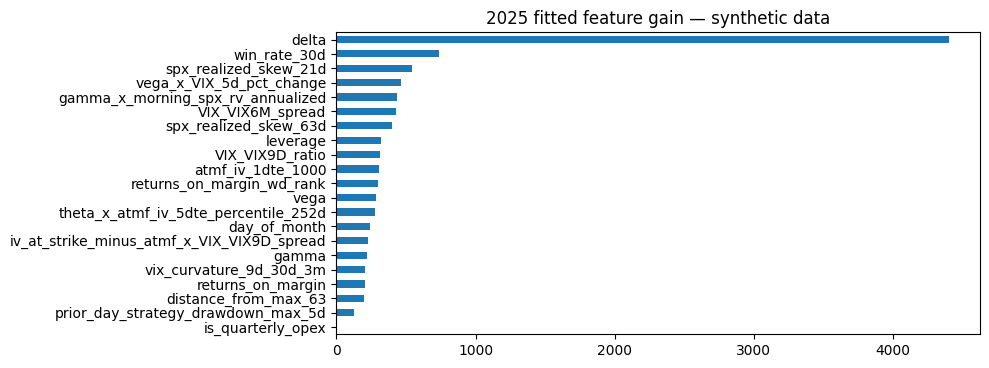

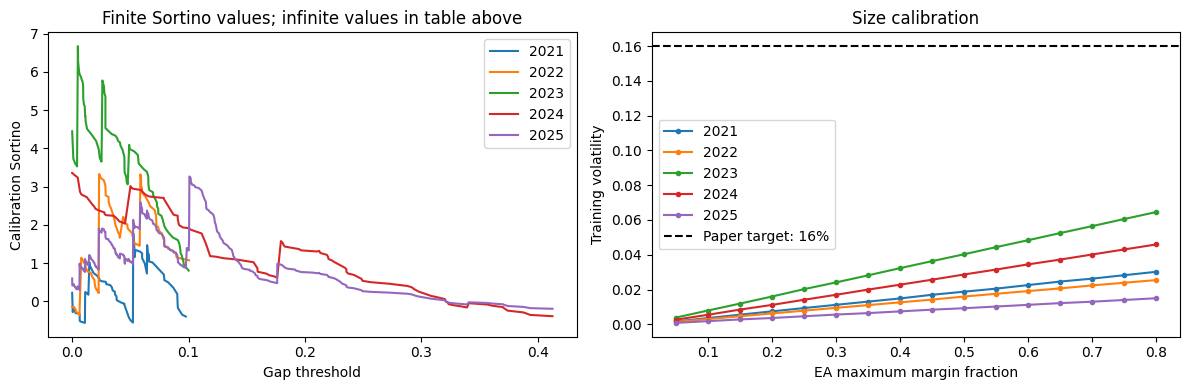

In [13]:
fit_summary = pd.DataFrame({year: dict(features=len(f['features']),
    trials=len(f['study'].trials), trees=f['model'].best_iteration,
    tuning_ndcg1=f['study'].best_value, future_ndcg1=f['prediction_ndcg1'],
    gate=f['threshold'], gate_days=len(f['gate_sample']),
    gate_candidates=len(f['gate_curve']), skip_grade=int(grades([0.], f['cuts'])[0]))
    for year, f in fits.items()}).T
display(fit_summary)
display(pd.DataFrame({y: f['study'].best_params for y, f in fits.items()}).T)
display(pd.DataFrame({y: f['sizing_parameters'] for y, f in fits.items()}).T)
gate_choices = pd.DataFrame({y: f['gate_curve'].set_index('threshold').loc[f['threshold']]
                            for y, f in fits.items()}).T
display(gate_choices.rename_axis('prediction_year'))
size_choices = pd.concat({y: f['size_curve'].set_index(['method', 'parameter']).loc[
    list(f['sizing_parameters'].items())] for y, f in fits.items()}, names=['prediction_year'])
display(size_choices[['annual_vol', 'trades']])

# One complete nine-row decision, using the first 2025 prediction date.
decision_date = fits[2025]['prediction_top'].index[0]
decision_mask = row_dates == decision_date
decision = panel.loc[decision_mask, ['premium', 'delta']].copy()
decision['predicted_score'] = fits[2025]['model'].predict(
    X.loc[decision_mask, fits[2025]['features']].to_numpy())
display(decision.sort_values('predicted_score', ascending=False, kind='stable'))
winner = fits[2025]['prediction_top'].loc[decision_date]
print('Decision:', decision_date.date(), winner.candidate, 'gap:', winner.gap,
      'threshold:', fits[2025]['threshold'],
      'passes both entry gates:', winner.candidate != 'SKIP' and winner.gap >= fits[2025]['threshold'])

survival = pd.DataFrame({y: pd.Series(True, index=f['features']) for y, f in fits.items()}).astype('boolean').fillna(False)
display(survival.assign(windows=survival.sum(axis=1)).sort_values('windows', ascending=False))
gain = pd.Series(fits[2025]['model'].feature_importance(importance_type='gain'),
                 index=fits[2025]['features']).sort_values()
gain.plot.barh(title='2025 fitted feature gain — synthetic data', figsize=(10, max(3, len(gain)*.18)))
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for year, fitted in fits.items():
    curve = fitted['gate_curve']
    axes[0].plot(curve.threshold, curve.sortino.replace([np.inf, -np.inf], np.nan), label=str(year))
    ea = fitted['size_curve'].query("method == 'EA'")
    axes[1].plot(ea.parameter, ea.annual_vol, marker='.', label=str(year))
axes[0].set(xlabel='Gap threshold', ylabel='Calibration Sortino', title='Finite Sortino values; infinite values in table above')
axes[1].axhline(.16, color='black', linestyle='--', label='Paper target: 16%')
axes[1].set(xlabel='EA maximum margin fraction', ylabel='Training volatility', title='Size calibration')
for ax in axes: ax.legend()
plt.tight_layout(); plt.show()

## 11. Walk-forward and hold-out results

Returns are calculated once on the ordered ledger, then sliced. The source's
headline Sharpe is **geometric annual return / annualized sample volatility**;
the arithmetic version is displayed separately. Drawdowns include the initial
NAV. Abstention days remain zeros. Strategy returns already represent the
source's excess-return convention, so EFFR is not subtracted a second time.

Controls below are synthetic SPX buy-and-hold and daily one-contract P25/P45
books. They are explicitly **not** the paper's external CBOE PUT/WPUT indices or
fully specified internal baselines. Hypothetical collateral interest is added
to the put controls' total returns, then removed for excess-return statistics.

days  trades  annual_return  annual_vol    sharpe  \
method split                                                             
FMU    WF 2021–2024   957     259      -0.027044    0.105517 -0.256300   
       OOT 2025       238      22       0.028794    0.005908  4.873842   
VT     WF 2021–2024   957     259      -0.052157    0.175975 -0.296390   
       OOT 2025       238      22       0.048520    0.009864  4.918764   
SRS    WF 2021–2024   957     259      -0.019057    0.089150 -0.213764   
       OOT 2025       238      22       0.025161    0.005174  4.862558   
EA     WF 2021–2024   957     255       0.000852    0.071738  0.011882   
       OOT 2025       238      22       0.017056    0.004223  4.038606   
GB     WF 2021–2024   957     259      -0.052087    0.174799 -0.297982   
       OOT 2025       238      22       0.048529    0.009866  4.918595   
HK     WF 2021–2024   957     149       0.001932    0.084014  0.022996   
       OOT 2025       238       6       0.011265    0.004572  2.463663   
QK     WF 2021–2024   957     149      -0.002624    0.083883 -0.031277   
       OOT 2025       238       6       0.011263    0.004571  2.463871   

                     arithmetic_sharpe   sortino  max_drawdown  
method split                                                    
FMU    WF 2021–2024          -0.202576 -0.258620      0.253713  
       OOT 2025               4.808200       inf      0.000000  
VT     WF 2021–2024          -0.202887 -0.299075      0.400972  
       OOT 2025               4.808514       inf      0.000000  
SRS    WF 2021–2024          -0.168180 -0.215908      0.213032  
       OOT 2025               4.805203       inf      0.000000  
EA     WF 2021–2024           0.049639  0.012095      0.153781  
       OOT 2025               4.006786       inf      0.000000  
GB     WF 2021–2024          -0.205076 -0.300615      0.400780  
       OOT 2025               4.808330       inf      0.000000  
HK     WF 2021–2024           0.069402  0.023297      0.154834  
       OOT 2025               2.452218       inf      0.000000  
QK     WF 2021–2024           0.015047 -0.031645      0.154782  
       OOT 2025               2.452426       inf      0.000000

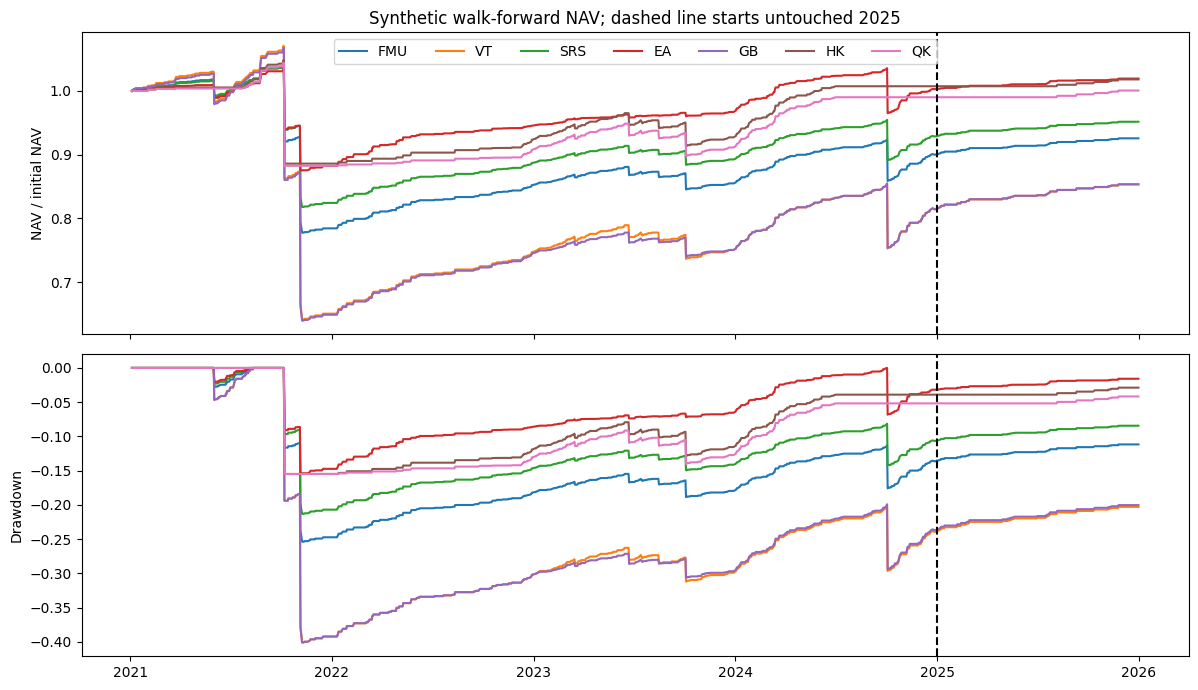

,annual_return,annual_vol,sharpe,arithmetic_sharpe,sortino,max_drawdown
SPX synthetic,-0.055742,0.209484,-0.266094,-0.168566,-0.359993,0.408581
Daily P25 synthetic,0.002744,0.002720,1.008641,1.008626,1.072914,0.003976
Daily P45 synthetic,0.002637,0.003778,0.698134,0.699107,0.791500,0.005361


In [14]:
def summarize_ledgers(collection):
    records = []
    for method, ledger in collection.items():
        for split, mask in [('WF 2021–2024', ledger.index.year < 2025),
                            ('OOT 2025', ledger.index.year == 2025)]:
            piece = ledger.loc[mask]
            records.append(dict(method=method, split=split, days=len(piece),
                                trades=int((piece.quantity > 0).sum()), **performance(piece.returns)))
    return pd.DataFrame(records).set_index(['method', 'split'])


summary = summarize_ledgers(ledgers)
display(summary)
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for method, ledger in ledgers.items():
    axes[0].plot(ledger.index, ledger.nav/NAV0, label=method)
    peak = np.maximum.accumulate(np.r_[NAV0, ledger.nav])[1:]
    axes[1].plot(ledger.index, ledger.nav/peak-1, label=method)
for ax in axes:
    ax.axvline(pd.Timestamp('2025-01-01'), color='black', linestyle='--')
axes[0].set(title='Synthetic walk-forward NAV; dashed line starts untouched 2025', ylabel='NAV / initial NAV')
axes[1].set(ylabel='Drawdown')
axes[0].legend(ncol=len(SIZE_GRIDS)); plt.tight_layout(); plt.show()

book_dates = ledgers['EA'].index
rf = market.effr.reindex(book_dates)/ANN
benchmark_total = pd.DataFrame(index=book_dates)
benchmark_total['SPX synthetic'] = market.close.pct_change().reindex(book_dates)
for candidate in ['P25', 'P45']:
    rows = panel.xs(candidate, level='candidate').reindex(book_dates)
    pnl = 100*rows.gross-entry_fee(1, rows.premium)
    prior_nav = NAV0+pnl.cumsum().shift(fill_value=0)
    benchmark_total[f'Daily {candidate} synthetic'] = pnl/prior_nav+rf
benchmark_excess = benchmark_total.sub(rf, axis=0)
display(pd.DataFrame({name: performance(values) for name, values in benchmark_excess.items()}).T)

## 12. PSR, DSR and pairwise testing

PSR/DSR use **daily arithmetic Sharpe**, daily skewness and **non-excess**
kurtosis. They do not use the geometric headline Sharpe. Sample-moment bias
correction is explicitly enabled here because the paper does not specify it.

DSR's printed formula uses `max(benchmark Sharpe, expected best null Sharpe)`;
its prose instead uses the null reference alone. Both are shown. The source's
75 trials are a paper-budget illustration only. Our exhaustive gate grid changes
the trial inventory, and its strongly dependent thresholds are not 75 independent
experiments. Neither DSR column certifies this synthetic strategy.

The daily-horizon DM-style test uses the sample variance of paired P&L
differences. Here both return series are expressed on the same fixed $5M base
for that comparison; multiplying both by $5M cancels from the statistic.
Bonferroni multiplies each p-value by the actual number of jointly reported controls.

In [15]:
def daily_sharpe(r):
    r = np.asarray(r, dtype=float)
    sd = r.std(ddof=1)
    return r.mean()/sd if sd > 0 else np.nan


def psr(r, reference):
    r = np.asarray(r, dtype=float)
    sr = daily_sharpe(r)
    skew = st.skew(r, bias=False)
    kurtosis = st.kurtosis(r, fisher=False, bias=False)
    variance = 1-skew*sr+(kurtosis-1)*sr**2/4
    return ndtr((sr-reference)*np.sqrt(len(r)-1)/np.sqrt(variance)) if variance > 0 else np.nan


def expected_max_null_sharpe(n_observations, n_trials):
    if n_observations < 2 or n_trials <= 1:
        raise ValueError('This asymptotic formula requires N > 1 and more than one trial.')
    return ((1-np.euler_gamma)*ndtri(1-1/n_trials) +
            np.euler_gamma*ndtri(1-1/(n_trials*np.e)))/np.sqrt(n_observations-1)


def paired_pvalue(a, b):
    difference = np.asarray(a)-np.asarray(b)
    se = difference.std(ddof=1)/np.sqrt(len(difference))
    return 2*st.norm.sf(abs(difference.mean()/se)) if se > 0 else np.nan


confidence = []
for method, ledger in ledgers.items():
    for split, mask in [('WF', ledger.index.year < 2025), ('OOT', ledger.index.year == 2025)]:
        r = ledger.loc[mask, 'returns']
        null_reference = expected_max_null_sharpe(len(r), 75)  # Published inventory, illustration only.
        for name in benchmark_excess:
            control = benchmark_excess.loc[r.index, name]
            reference = daily_sharpe(control)
            pvalue = paired_pvalue(r, control)
            confidence.append(dict(method=method, split=split, control=name,
                psr=psr(r, reference), dsr_printed_paper75=psr(r, max(reference, null_reference)),
                dsr_prose_paper75=psr(r, null_reference),
                paired_p=pvalue, bonferroni_p=np.minimum(1., len(benchmark_excess.columns)*pvalue)))
confidence = pd.DataFrame(confidence).set_index(['method', 'split', 'control'])
display(confidence)
print('Actual evaluated gate thresholds:', sum(len(f['gate_curve']) for f in fits.values()))

psr  dsr_printed_paper75  \
method split control                                              
FMU    WF    SPX synthetic        0.506521             0.000747   
             Daily P25 synthetic  0.014031             0.000747   
             Daily P45 synthetic  0.048736             0.000747   
       OOT   SPX synthetic        1.000000             0.999991   
             Daily P25 synthetic  0.999971             0.999971   
             Daily P45 synthetic  1.000000             0.999991   
VT     WF    SPX synthetic        0.506249             0.000745   
             Daily P25 synthetic  0.014007             0.000745   
             Daily P45 synthetic  0.048668             0.000745   
       OOT   SPX synthetic        1.000000             0.999991   
             Daily P25 synthetic  0.999971             0.999971   
             Daily P45 synthetic  1.000000             0.999991   
SRS    WF    SPX synthetic        0.535715             0.001224   
             Daily P25 synthetic  0.019098             0.001224   
             Daily P45 synthetic  0.061074             0.001224   
       OOT   SPX synthetic        1.000000             0.999990   
             Daily P25 synthetic  0.999970             0.999970   
             Daily P45 synthetic  1.000000             0.999990   
EA     WF    SPX synthetic        0.688922             0.011568   
             Daily P25 synthetic  0.077339             0.011568   
             Daily P45 synthetic  0.169455             0.011568   
       OOT   SPX synthetic        1.000000             0.998977   
             Daily P25 synthetic  0.997439             0.997439   
             Daily P45 synthetic  1.000000             0.998977   
GB     WF    SPX synthetic        0.504350             0.000707   
             Daily P25 synthetic  0.013582             0.000707   
             Daily P45 synthetic  0.047639             0.000707   
       OOT   SPX synthetic        1.000000             0.999991   
             Daily P25 synthetic  0.999971             0.999971   
             Daily P45 synthetic  1.000000             0.999991   
HK     WF    SPX synthetic        0.696427             0.015169   
             Daily P25 synthetic  0.089556             0.015169   
             Daily P45 synthetic  0.186509             0.015169   
       OOT   SPX synthetic        0.999999             0.460079   
             Daily P25 synthetic  0.354969             0.354969   
             Daily P45 synthetic  0.959974             0.460079   
QK     WF    SPX synthetic        0.667453             0.008936   
             Daily P25 synthetic  0.065667             0.008936   
             Daily P45 synthetic  0.150169             0.008936   
       OOT   SPX synthetic        0.999999             0.460243   
             Daily P25 synthetic  0.355127             0.355127   
             Daily P45 synthetic  0.960002             0.460243   

                                  dsr_prose_paper75  paired_p  bonferroni_p  
method split control                                                         
FMU    WF    SPX synthetic                 0.000747  0.830924      1.000000  
             Daily P25 synthetic           0.000747  0.658291      1.000000  
             Daily P45 synthetic           0.000747  0.659696      1.000000  
       OOT   SPX synthetic                 0.999991  0.898784      1.000000  
             Daily P25 synthetic           0.999991  0.000177      0.000530  
             Daily P45 synthetic           0.999991  0.000473      0.001419  
VT     WF    SPX synthetic                 0.000745  0.941080      1.000000  
             Daily P25 synthetic           0.000745  0.671721      1.000000  
             Daily P45 synthetic           0.000745  0.672553      1.000000  
       OOT   SPX synthetic                 0.999991  0.823786      1.000000  
             Daily P25 synthetic           0.999991  0.000034      0.000102  
             Daily P45 synthetic           0.999991  0.000057      0.000172 

Actual evaluated gate thresholds: 885


## 13. Retrospective regime attribution and fixed-position execution stress

Regime tables use **entry-day closing** VIX and realized volatility. They are
retrospective descriptions, never entry signals. VIX bins are the source's
`<15`, `15–25`, `>25`; RV tercile cut points are fitted separately within WF and
OOT. Exact-cut ties go to the lower band here, an explicit missing source choice.

Execution stress holds the original candidate, gate and **integer contract
count** fixed. Replace entry mid with 75% bid + 25% ask, then bid. Recompute fees
at the changed premium and chain the changed cash P&L. Do not resize or retrain.

In [16]:
regime_records = []
for split, year_mask in [('WF', book_dates.year < 2025), ('OOT', book_dates.year == 2025)]:
    sample_dates = book_dates[year_mask]
    closing_vix = market.VIX.reindex(sample_dates)
    vix_regime = pd.Series(np.where(closing_vix < 15, 'low', np.where(closing_vix <= 25, 'mid', 'high')),
                           index=sample_dates)
    closing_rv = np.sqrt(market.intraday_sumsq.rolling(5).mean()).reindex(sample_dates)
    cuts = closing_rv.quantile([1/3, 2/3]).to_numpy()
    rv_regime = pd.Series(np.searchsorted(cuts, closing_rv, side='left')+1, index=sample_dates)
    for axis, labels in [('VIX', vix_regime), ('RV tercile', rv_regime)]:
        for regime in labels.unique():
            selected_dates = labels.index[labels == regime]
            for method, ledger in ledgers.items():
                piece = ledger.loc[selected_dates]
                regime_records.append(dict(split=split, axis=axis, regime=regime, method=method,
                    days=len(piece), trades=int((piece.quantity > 0).sum()), **performance(piece.returns)))
regime_results = pd.DataFrame(regime_records)
display(regime_results[regime_results.method == 'EA'])


def reprice_fixed_positions(ledger, spread_coverage):
    result = ledger.copy()
    premium = spread_coverage*result.bid+(1-spread_coverage)*result.ask
    q = result.quantity.to_numpy()
    fee = entry_fee(q, premium)
    pnl = np.where(q > 0, 100*q*(premium-result.payoff)-fee, 0.)
    before = NAV0+pd.Series(pnl, index=result.index).cumsum().shift(fill_value=0)
    result['pnl'], result['fee'] = pnl, fee
    result['nav_before'], result['nav'] = before, before+pnl
    result['returns'] = pnl/before
    result['premium'] = premium
    return result


stress_ledgers = {coverage: {m: reprice_fixed_positions(l, coverage) for m, l in ledgers.items()}
                  for coverage in [.50, .75, 1.]}
stress_results = pd.concat({coverage: summarize_ledgers(collection)
                           for coverage, collection in stress_ledgers.items()}, names=['spread_coverage'])
display(stress_results[['sharpe', 'annual_return', 'annual_vol', 'max_drawdown']])

,split,axis,regime,method,days,trades,annual_return,annual_vol,sharpe,arithmetic_sharpe,sortino,max_drawdown
3,WF,VIX,low,EA,246,60,-0.003868,0.020599,-0.187758,-0.177728,-0.190380,0.020061
10,WF,VIX,mid,EA,416,112,0.041714,0.009195,4.536686,4.449567,6.974861,0.006802
17,WF,VIX,high,EA,295,83,-0.050324,0.127455,-0.394839,-0.338075,-0.401388,0.153810
24,WF,RV tercile,1,EA,319,67,0.023953,0.004175,5.737770,5.672475,23.204354,0.000953
31,WF,RV tercile,2,EA,319,102,-0.017032,0.064448,-0.264279,-0.233019,-0.267669,0.068301
38,WF,RV tercile,3,EA,319,86,-0.003928,0.106289,-0.036955,0.019005,-0.037707,0.153781
45,OOT,VIX,mid,EA,103,13,0.022290,0.004082,5.460560,5.402848,inf,0.000000
52,OOT,VIX,high,EA,82,6,0.020412,0.005493,3.716319,3.681755,inf,0.000000
59,OOT,VIX,low,EA,53,3,0.001841,0.000646,2.851784,2.849488,inf,0.000000
66,OOT,RV tercile,2,EA,79,7,0.028158,0.006209,4.535245,4.475875,inf,0.000000


sharpe  annual_return  annual_vol  \
spread_coverage method split                                               
0.50            FMU    WF 2021–2024 -0.256300      -0.027044    0.105517   
                       OOT 2025      4.873842       0.028794    0.005908   
                VT     WF 2021–2024 -0.296390      -0.052157    0.175975   
                       OOT 2025      4.918764       0.048520    0.009864   
                SRS    WF 2021–2024 -0.213764      -0.019057    0.089150   
                       OOT 2025      4.862558       0.025161    0.005174   
                EA     WF 2021–2024  0.011882       0.000852    0.071738   
                       OOT 2025      4.038606       0.017056    0.004223   
                GB     WF 2021–2024 -0.297982      -0.052087    0.174799   
                       OOT 2025      4.918595       0.048529    0.009866   
                HK     WF 2021–2024  0.022996       0.001932    0.084014   
                       OOT 2025      2.463663       0.011265    0.004572   
                QK     WF 2021–2024 -0.031277      -0.002624    0.083883   
                       OOT 2025      2.463871       0.011263    0.004571   
0.75            FMU    WF 2021–2024 -0.265110      -0.028005    0.105634   
                       OOT 2025      4.873354       0.028609    0.005870   
                VT     WF 2021–2024 -0.304730      -0.053728    0.176313   
                       OOT 2025      4.918269       0.048330    0.009827   
                SRS    WF 2021–2024 -0.223095      -0.019909    0.089241   
                       OOT 2025      4.862099       0.024987    0.005139   
                EA     WF 2021–2024  0.001605       0.000115    0.071798   
                       OOT 2025      4.038301       0.016930    0.004192   
                GB     WF 2021–2024 -0.305982      -0.053583    0.175118   
                       OOT 2025      4.918067       0.048325    0.009826   
                HK     WF 2021–2024  0.014845       0.001248    0.084057   
                       OOT 2025      2.463563       0.011179    0.004538   
                QK     WF 2021–2024 -0.038898      -0.003265    0.083925   
                       OOT 2025      2.463770       0.011176    0.004536   
1.00            FMU    WF 2021–2024 -0.273926      -0.028968    0.105752   
                       OOT 2025      4.872861       0.028422    0.005833   
                VT     WF 2021–2024 -0.313077      -0.055306    0.176653   
                       OOT 2025      4.917767       0.048138    0.009789   
                SRS    WF 2021–2024 -0.232429      -0.020763    0.089332   
                       OOT 2025      4.861635       0.024813    0.005104   
                EA     WF 2021–2024 -0.008676      -0.000623    0.071859   
                       OOT 2025      4.037994       0.016803    0.004161   
                GB     WF 2021–2024 -0.313987      -0.055086    0.175440   
                       OOT 2025      4.917532       0.048118    0.009785   
                HK     WF 2021–2024  0.006687       0.000562    0.084101   
                       OOT 2025      2.463463       0.011094    0.004503   
                QK     WF 2021–2024 -0.046525      -0.003907    0.083966   
                       OOT 2025      2.463669       0.011089    0.004501   

                                     max_drawdown  
spread_coverage method split                       
0.50            FMU    WF 2021–2024      0.253713  
                       OOT 2025          0.000000  
                VT     WF 2021–2024      0.400972  
                       OOT 2025          0.000000  
                SRS    WF 2021–2024      0.213032  
                       OOT 2025          0.000000  
                EA     WF 2021–2024      0.153781  
                       OOT 2025          0.000000  
                GB     WF 2021–2024      0.400780  
                       OOT 2025          0.000000  
                HK     WF 2021–2024      0.154834  
                  

## 14. Optional complete robustness reruns

These functions execute the same annual pipeline; they do not approximate an
ablation by setting a fitted model's feature to zero. Source-tagged deletion
removes a group's derived products/ranks too, **before S1–S5**, then reruns
feature selection, tuning, refitting, gate and sizing calibration.

The next switch is off because these are additional studies, beyond the main
five-window demonstration. Turn it on to run the paper's fifteen feature-group
ablations, its four gate/tail combinations, and its ten structural perturbations.
The paper's 25/100-trial and .90/.95-correlation variants are actual alternative
study settings, not computational shortcuts for the headline.

For the ambiguous "two-year window" perturbation, we explicitly choose an
expanding history beginning in 2019 while retaining prediction years 2021–2025.
The other training variant is rolling three years.

In [17]:
TAIL_FEATURES = ['rv_surprise_5d', 'prior_day_strategy_drawdown_max_5d', 'vix_z_60d']
STRUCTURAL_VARIANTS = {
    'initial two years': {'history': 'initial_2y'},
    'rolling three years': {'history': 'rolling_3y'},
    '12% volatility anchor': {'target_vol': .12},
    '20% volatility anchor': {'target_vol': .20},
    '25 tuning trials': {'trials': 25},
    '100 tuning trials': {'trials': 100},
    '.95 correlation': {'correlation_threshold': .95},
    '.90 correlation': {'correlation_threshold': .90},
    'Sharpe size calibration': {'size_objective': 'sharpe'},
    'Sortino size calibration': {'size_objective': 'sortino'},
}


def robustness_studies():
    feature_ablations = {group: run_experiment(drop_groups=[group]) for group in GROUP_ORDER}
    controls = {(True, True): experiment}
    for gate, tails in itertools.product([False, True], repeat=2):
        if (gate, tails) != (True, True):
            controls[gate, tails] = run_experiment(use_gate=gate, drop_features=[] if tails else TAIL_FEATURES)
    structural = {name: run_experiment(**settings) for name, settings in STRUCTURAL_VARIANTS.items()}
    ablation_table = pd.concat({group: summarize_ledgers(run['ledgers'])
                               for group, run in feature_ablations.items()}, names=['removed_group'])
    ablation_table['delta_sharpe'] = (ablation_table.sharpe-
        summary.sharpe.reindex(ablation_table.index.droplevel('removed_group')).to_numpy())
    control_sharpes = {key: summarize_ledgers(run['ledgers']).loc['EA', 'sharpe']
                      for key, run in controls.items()}
    decomposition = pd.DataFrame({
        'base': control_sharpes[False, False],
        'gate effect': control_sharpes[True, False]-control_sharpes[False, False],
        'tail effect': control_sharpes[False, True]-control_sharpes[False, False],
        'interaction': (control_sharpes[True, True]-control_sharpes[True, False]
                        -control_sharpes[False, True]+control_sharpes[False, False]),
    })
    structural_table = pd.concat({name: summarize_ledgers(run['ledgers'])
                                 for name, run in structural.items()}, names=['perturbation'])
    return ablation_table, decomposition, structural_table


RUN_ADDITIONAL_STUDIES = False
if RUN_ADDITIONAL_STUDIES:
    ablation_table, decomposition, structural_table = robustness_studies()
    display(ablation_table, decomposition, structural_table)
else:
    print('Additional studies are defined, not executed. Headline and execution repricing ran in full.')

Additional studies are defined, not executed. Headline and execution repricing ran in full.


## 15. Runnable correctness checks

These checks establish the mechanics, not profitability: path-label arithmetic,
threshold boundaries, causal feature timing, group integrity, training-date
separation, source group caps, selected-column fidelity, abstention, integer
margin constraints, NAV continuity, and unchanged quantities under repricing.
No check demands that synthetic Sharpe or feature survival match published results.

In [18]:
def check_notebook():
    # Independent hand-worked path: 10 -> 8 -> 12 -> 5 gives G=5, downside=4.
    changes = -np.diff([10., 8., 12., 5.])
    assert changes.sum() == 5.
    assert np.sqrt(np.minimum(changes, 0).dot(np.minimum(changes, 0))) == 4.
    np.testing.assert_array_equal(grades([-3, -2, 0, 2, 4, 5], [-2, 0, 2, 4]), [0, 0, 1, 2, 3, 4])
    # No candidate identity or future label is an input feature.
    assert not {'candidate', 'z', 'gross', 'payoff', 'downside', 'target_delta'} & set(X)
    assert len(products) == 7
    assert catalog.group.nunique() == 15
    assert not np.isinf(X.to_numpy()).any()
    assert X.loc[~real, 'delta'].isna().all()
    assert X.loc[~real, 'returns_on_margin'].eq(0).all()
    assert X.loc[~real, 'entry_log_premium_wd_rank'].eq(8.5).all()
    assert panel.groupby(level='date').size().eq(9).all()

    # Reconstruct the interaction independently on eligible-date matrices.
    delta_matrix = panel.delta.unstack('candidate')
    vix_observation = market.VIX.reindex(delta_matrix.index)
    expected = delta_matrix.mul(vix_observation, axis=0).shift().stack(future_stack=True)
    pd.testing.assert_series_equal(X.delta_x_VIX, expected.reindex(X.index), check_names=False)
    # Today's feature ROM must come from that bucket's previous eligible outcome.
    expected_rom = (panel.gross/panel.premium).groupby(level='candidate').shift()
    np.testing.assert_allclose(X.loc[real, 'returns_on_margin'], expected_rom.loc[real], equal_nan=True)

    cap_by_group = {'position': 8, 'vol_surface': 4, 'vix': 6, 'calendar': 8}
    archived_dates = []
    for year, f in fits.items():
        roles = f['roles']
        assert roles['start'] < roles['tune_start'] < roles['stop_start'] < roles['gate_start'] < roles['prediction_start']
        assert row_dates[f['refit_fit']].max() < roles['stop_start']
        assert f['gate_sample'].index.max() < roles['prediction_start']
        assert f['prediction_top'].index.min() >= roles['prediction_start']
        assert f['study'].trials_dataframe().state.eq('COMPLETE').sum() == PAPER_TRIALS
        assert f['model'].feature_name() == f['features']
        assert f['audit'].loc[f['features'], 'fold_survival'].ge(2).all()
        for group, count in catalog.loc[f['features']].groupby('group').size().items():
            assert count <= cap_by_group.get(group, 5)
        assert len(f['size_curve']) == 148
        if year < 2025:
            archived_dates.extend(f['gate_sample'].index)
    assert pd.DatetimeIndex(archived_dates).sort_values().equals(fits[2025]['gate_sample'].index)

    for method, ledger in ledgers.items():
        assert ledger.index.is_unique and ledger.index.is_monotonic_increasing
        assert (ledger.quantity >= 0).all()
        assert np.equal(ledger.quantity, np.floor(ledger.quantity)).all()
        traded = ledger.quantity > 0
        assert (ledger.loc[traded, 'quantity']*ledger.loc[traded, 'margin'] <= ledger.loc[traded, 'nav_before']).all()
        assert ledger.loc[~traded, ['fee', 'pnl', 'returns']].eq(0).all().all()
        assert not (traded & ledger.candidate.eq('SKIP')).any()
        np.testing.assert_allclose(ledger.nav, NAV0+ledger.pnl.cumsum())
        np.testing.assert_allclose(ledger.nav_before.iloc[1:], ledger.nav.iloc[:-1])
        for coverage in [.50, .75, 1.]:
            pd.testing.assert_series_equal(stress_ledgers[coverage][method].quantity, ledger.quantity)
        np.testing.assert_allclose(stress_ledgers[.50][method].nav, ledger.nav)
    assert float(entry_fee(0, .01)) == 0.
    assert float(entry_fee(1, .01)) == 1.
    assert float(entry_fee(10, .10)) == 6.5
    assert regt_margin(10., 5000., 4900.) == 100*(10+650)
    f = fits[2021]
    blocked = simulate(f['prediction_top'], 'FMU', f['sizing_parameters']['FMU'],
                       f['sizing_constants'], threshold=np.inf)
    assert blocked[['quantity', 'fee', 'pnl', 'returns']].eq(0).all().all()
    print('All notebook correctness checks passed.')


check_notebook()
print(f'Total elapsed: {time.perf_counter()-started:.1f} seconds.')

All notebook correctness checks passed.
Total elapsed: 53.9 seconds.


## Adapting the walkthrough to your 14 items

Replace the synthetic observation/candidate builder with one row per real
item/date, retain a consistent feature schema, and build economically comparable
outcome labels. The grouping code already counts actual rows per date: fourteen
items work, or fifteen rows if fourteen tradable items are joined by SKIP.

The eight delta targets, rank-8.5 SKIP convention, and checks expecting nine rows
are **paper-specific**, so update those deliberately. Greek/IV features apply to
options; for other structures substitute meaningful exposure, pricing and
history descriptors. Features common to every item provide context but do not
identify an item by themselves.

Keep the temporal boundaries, completed-outcome lags, held-out gate, and separate
size calibration visible. Validate changes on future dates; do not tune to the
synthetic performance tables above.